## https://www.kaggle.com/code/eisgandar/car-prices-predict-with-ensemble-methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
os.getcwd()

/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car details v4.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv


'/kaggle/working'

## Load Dataset && get initial information

In [3]:
car = pd.read_csv("../input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv")
df = car.copy()
df.head().style.background_gradient(cmap = "autumn")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.000000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.000000
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.000000
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.000000
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.000000


In [4]:
df.shape

(8128, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [6]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

- There are null values in 'mileage' (221), 'engine' (221), 'max_power' (215), 'torque' (222), - 'seats' (221) variables.
- The dataset consists of 8128 rows and 13 columns.
- Of the variables, 9 are object, 3 are integer and 1 are float.

## Dataset-Level Preprocessing
Converting values of the columns and change dtypes

In [7]:
df.head(5).style.background_gradient(cmap='autumn')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.000000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.000000
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.000000
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.000000
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.000000


In [8]:
#make dtypes of some variables 'category'
category_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in category_cols:
    df[col] = df[col].astype('category')

In [9]:
#create 'car_brand_name' feature from 'name' feature
df["car_brand_name"] = df["name"].str.extract('([^\s]+)')
df["car_brand_name"] = df["car_brand_name"].astype("category")

In [10]:
#extract values of 'engine' and 'mileage' variables
df["mileage"] = df["mileage"].str.extract('([^\s]+)').astype("float")
df["engine"] = df["engine"].str.extract('([^\s]+)').astype("float")

In [11]:
#extract values of 'max_power' variable
df["max_power"] = df["max_power"].str.extract('([^\s]+)')
df["max_power"] = df["max_power"][~(df["max_power"] == "bhp")]
df["max_power"] = df["max_power"].astype("float")

In [12]:
import datetime

#create 'car_age' feature from 'year' column
df["car_age"] = (datetime.datetime.now().year) - (df["year"])

In [13]:
df.drop(["name", "year", "torque"], axis = 1, inplace = True)

In [14]:
df.head().style.background_gradient(cmap="summer")

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_brand_name,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.400000,1248.000000,74.000000,5.000000,Maruti,12
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.140000,1498.000000,103.520000,5.000000,Skoda,12
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.700000,1497.000000,78.000000,5.000000,Honda,20
3,225000,127000,Diesel,Individual,Manual,First Owner,23.000000,1396.000000,90.000000,5.000000,Hyundai,16
4,130000,120000,Petrol,Individual,Manual,First Owner,16.100000,1298.000000,88.200000,5.000000,Maruti,19


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   selling_price   8128 non-null   int64   
 1   km_driven       8128 non-null   int64   
 2   fuel            8128 non-null   category
 3   seller_type     8128 non-null   category
 4   transmission    8128 non-null   category
 5   owner           8128 non-null   category
 6   mileage         7907 non-null   float64 
 7   engine          7907 non-null   float64 
 8   max_power       7912 non-null   float64 
 9   seats           7907 non-null   float64 
 10  car_brand_name  8128 non-null   category
 11  car_age         8128 non-null   int64   
dtypes: category(5), float64(4), int64(3)
memory usage: 486.3 KB


In [16]:
df.isnull().sum()

selling_price       0
km_driven           0
fuel                0
seller_type         0
transmission        0
owner               0
mileage           221
engine            221
max_power         216
seats             221
car_brand_name      0
car_age             0
dtype: int64

In [17]:
df.describe().T.style.background_gradient(cmap = "viridis")

,count,mean,std,min,25%,50%,75%,max
selling_price,8128.000000,638271.807702,806253.403508,29999.000000,254999.000000,450000.000000,675000.000000,10000000.000000
km_driven,8128.000000,69819.510827,56550.554958,1.000000,35000.000000,60000.000000,98000.000000,2360457.000000
mileage,7907.000000,19.418783,4.037145,0.000000,16.780000,19.300000,22.320000,42.000000
engine,7907.000000,1458.625016,503.916303,624.000000,1197.000000,1248.000000,1582.000000,3604.000000
max_power,7912.000000,91.517919,35.822499,0.000000,68.050000,82.000000,102.000000,400.000000
seats,7907.000000,5.416719,0.959588,2.000000,5.000000,5.000000,5.000000,14.000000
car_age,8128.000000,12.195989,4.044249,6.000000,9.000000,11.000000,15.000000,43.000000


In [18]:
df.describe(include = "category").T

,count,unique,top,freq
fuel,8128,4,Diesel,4402
seller_type,8128,3,Individual,6766
transmission,8128,2,Manual,7078
owner,8128,5,First Owner,5289
car_brand_name,8128,32,Maruti,2448


- Car brand name with highest frequency: Maruti (freq = 2448)
- Fuel kind with highest frequency: Diesel (freq = 4402)
- Seller type with highest frequency: Individual (freq = 6766)
- Transmission type with highest frequency: Manual (freq = 7078)
- Owner type with highest frequency: First owner (freq = 5289)

## Visualize Missing Values and Handling them

<Axes: >

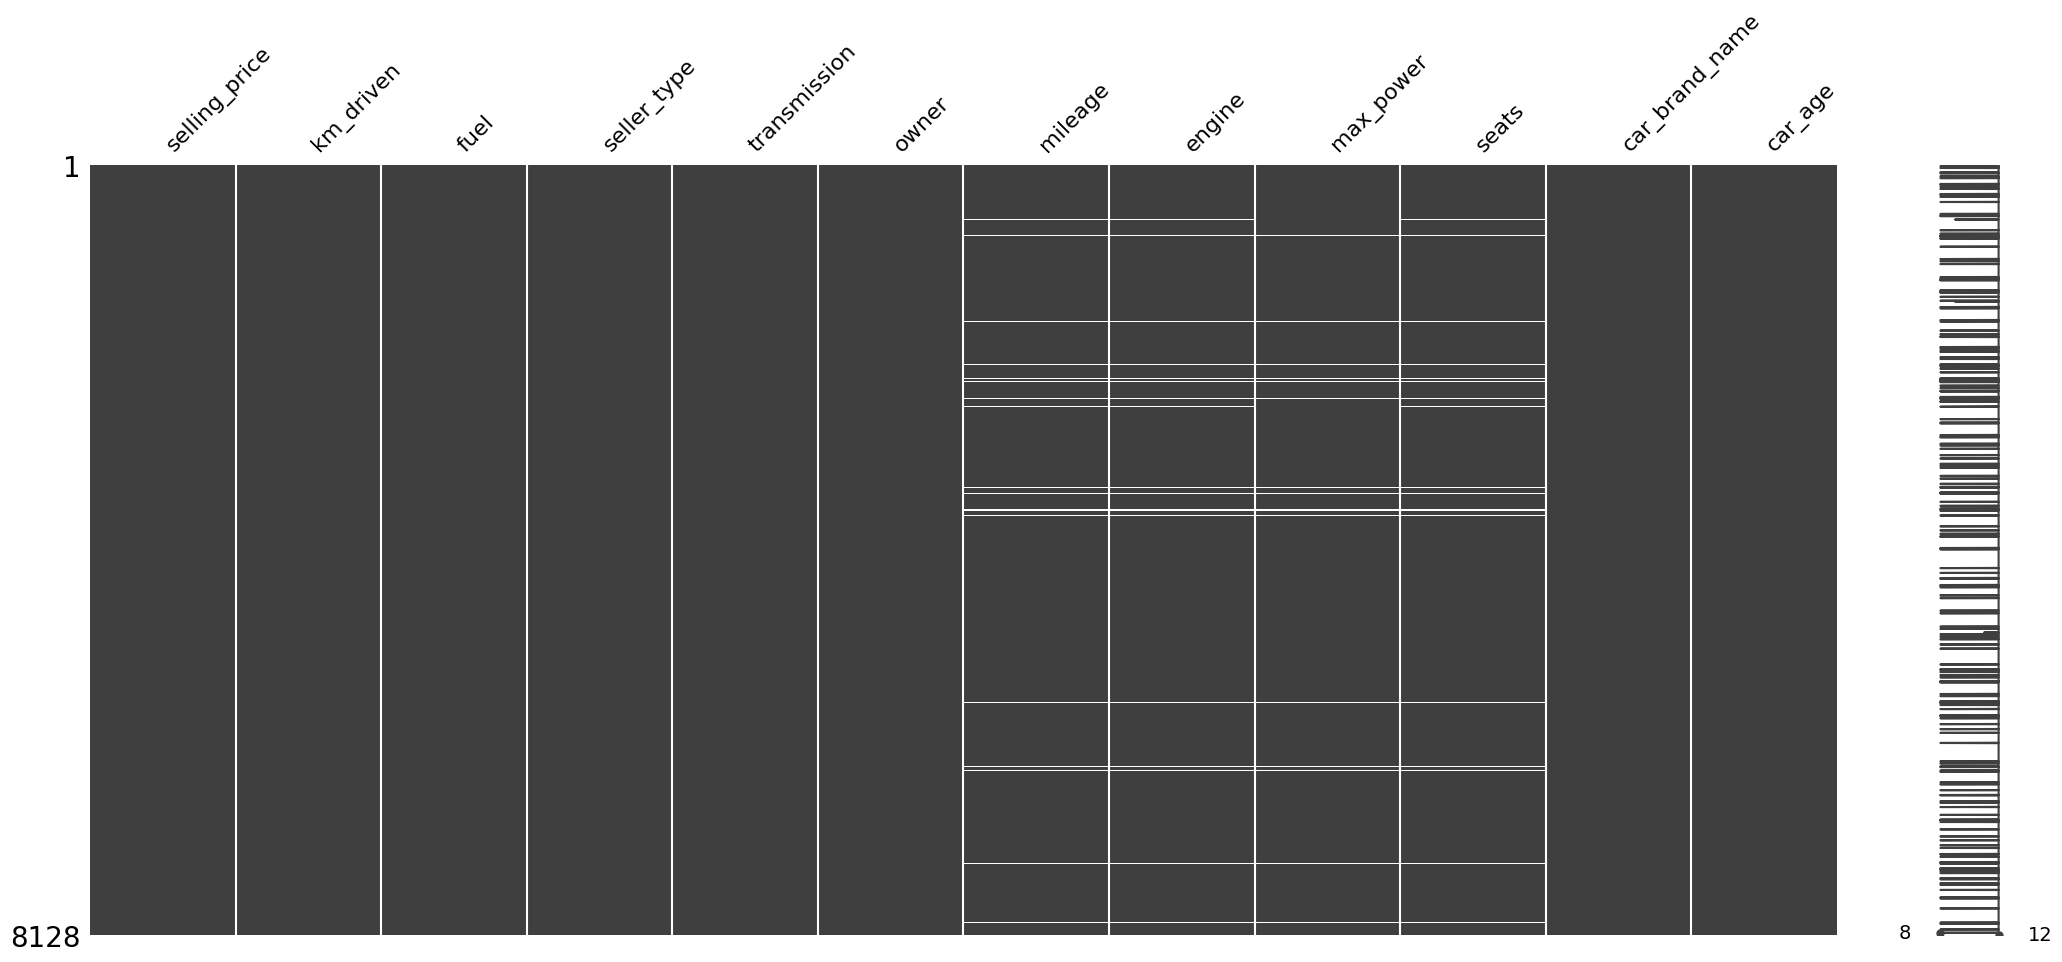

In [19]:
import missingno as msno

msno.matrix(df)

<Figure size 1000x500 with 0 Axes>

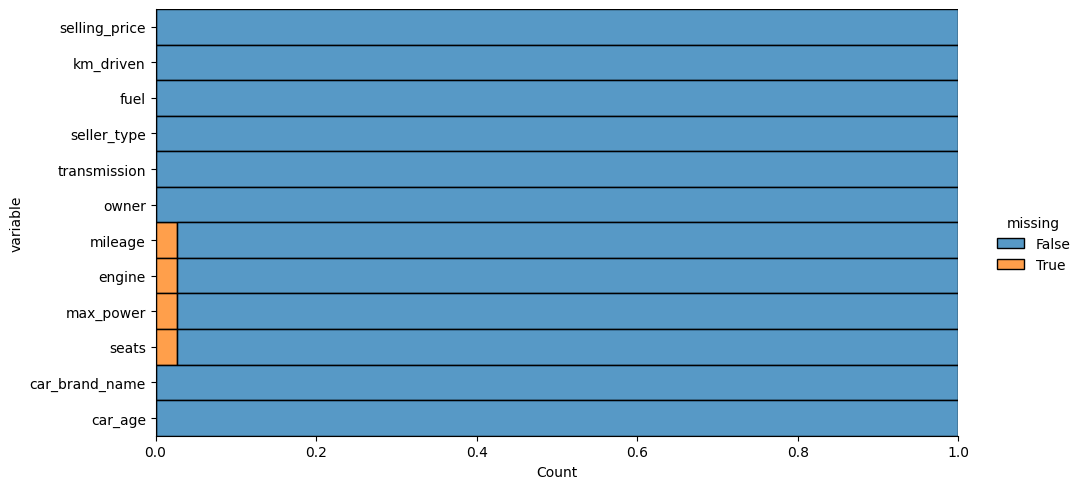

In [20]:
# visualize missing values with seaborn (distplot)
plt.figure(figsize = (10, 5))
sns.displot(data = df.isna().melt(value_name = "missing"), y = "variable",
    hue = "missing", multiple = "fill", aspect = 2);

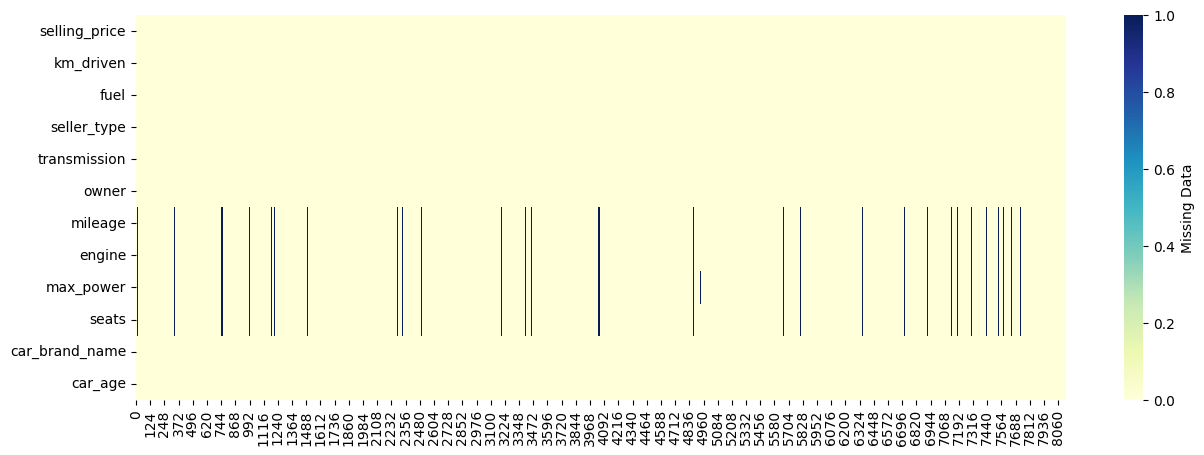

In [21]:
# visualize missing values with seaborn (heatmap)
plt.figure(figsize = (15, 5))
sns.heatmap(df.isna().transpose(), cmap = "YlGnBu", cbar_kws = {'label': 'Missing Data'});

In [22]:
# Fill null values with Median (numeric) and Mode (category)
numeric_cols = [col for col in df.select_dtypes(include=['int', 'float'])]
category_cols = [col for col in df.select_dtypes(exclude=['int', 'float'])]

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)
for col in category_cols:
    df[col].fillna(df.describe(exclude=['int', 'float']).T.loc[col, 'top'], inplace=True)
    # df.describe(include="category")[col].top
    # df.describe(include="category").loc['top', col]
    # df.describe(include="category").T.top[col]
    # df.describe(include="category").T.loc[col, 'top']
    # df[col] = df[col].fillna(df[col].mode()[0], inplace=True)
    # df[col].fillna(df[col].value_counts().index[0], inplace = True)

In [23]:
df.isnull().sum().sum()

np.int64(0)

In [24]:
#get class frequencies of some variables
print("Class frequencies of 'fuel' variable: \n\n", df["fuel"].value_counts())
print("_____________________________________________________________________________________")
print("Class frequencies of 'transmission' variable: \n\n", df["transmission"].value_counts())
print("_____________________________________________________________________________________")
print("Class frequencies of 'seller_type' variable: \n\n", df["seller_type"].value_counts())
print("_____________________________________________________________________________________")
print("Class frequencies of 'owner' variable: \n\n", df["owner"].value_counts())
print("_____________________________________________________________________________________")
print("Class frequencies of 'car_brand_name' variable: \n\n", df["car_brand_name"].value_counts())

Class frequencies of 'fuel' variable: 

 fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64
_____________________________________________________________________________________
Class frequencies of 'transmission' variable: 

 transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64
_____________________________________________________________________________________
Class frequencies of 'seller_type' variable: 

 seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64
_____________________________________________________________________________________
Class frequencies of 'owner' variable: 

 owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64
_____________________________________________________________________________________
Class frequencies of

In [25]:
df.corr(numeric_only=True).style.background_gradient(cmap="copper")

,selling_price,km_driven,mileage,engine,max_power,seats,car_age
selling_price,1.000000,-0.225534,-0.125454,0.453567,0.744958,0.041161,-0.414092
km_driven,-0.225534,1.000000,-0.171426,0.203954,-0.037714,0.225172,0.418006
mileage,-0.125454,-0.171426,1.000000,-0.575831,-0.373586,-0.452085,-0.310383
engine,0.453567,0.203954,-0.575831,1.000000,0.702152,0.610309,-0.017773
max_power,0.744958,-0.037714,-0.373586,0.702152,1.000000,0.191435,-0.213282
seats,0.041161,0.225172,-0.452085,0.610309,0.191435,1.000000,0.008623
car_age,-0.414092,0.418006,-0.310383,-0.017773,-0.213282,0.008623,1.000000


## Visualization and EDA

Boxplot

<Axes: xlabel='mileage'>

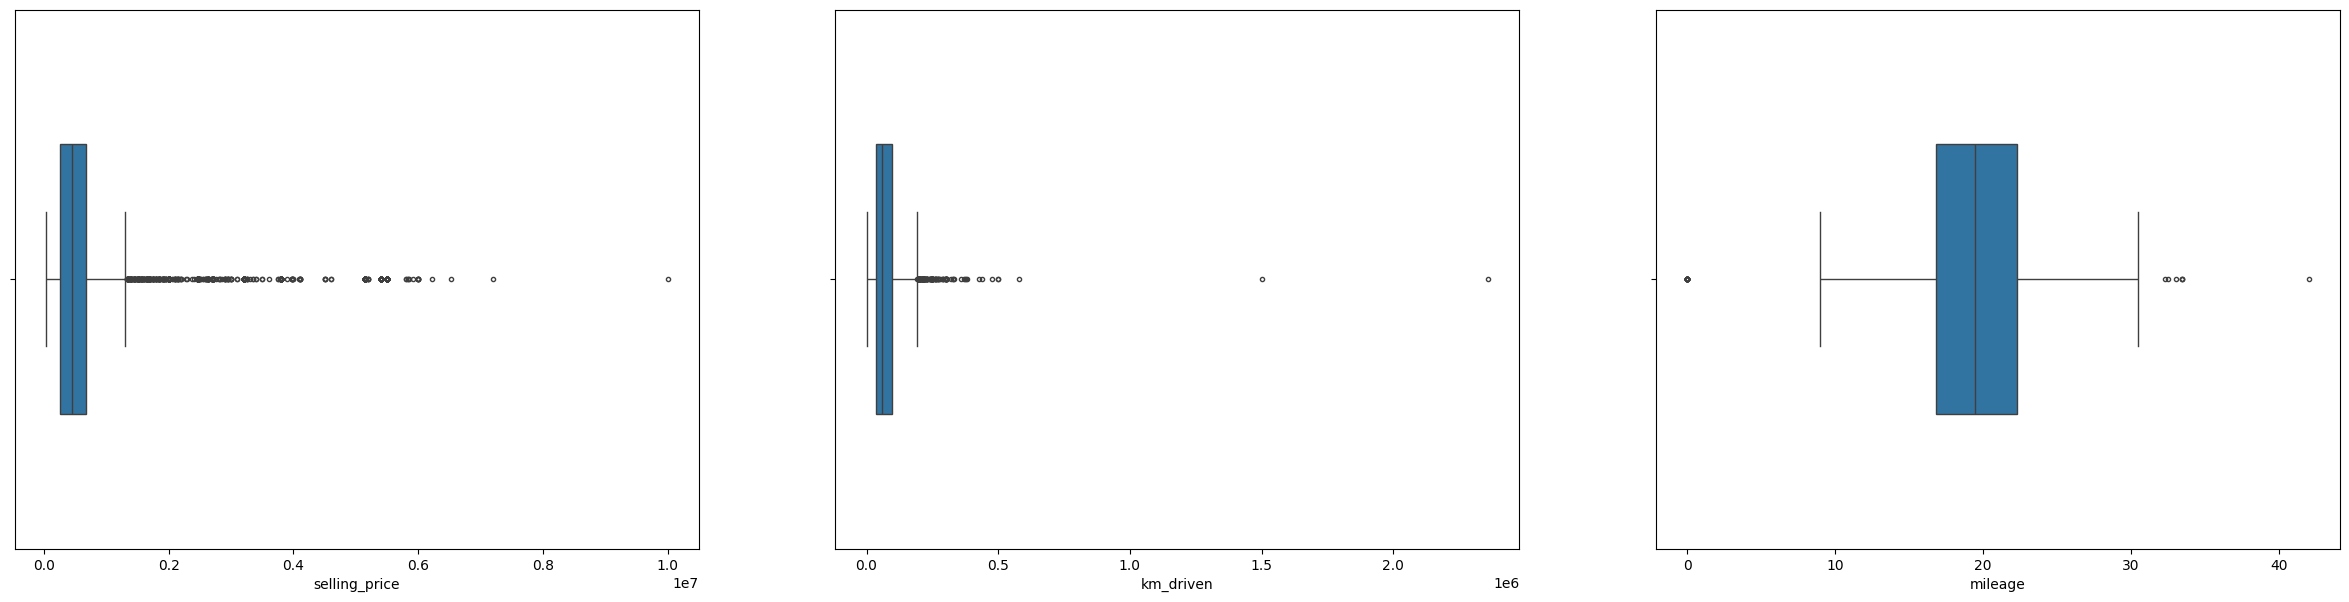

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(30, 7))
sns.boxplot(ax=axes[0], x='selling_price', data=df, width=0.5, fliersize=3, linewidth=1)
sns.boxplot(ax=axes[1], x='km_driven', data=df, width=0.5, fliersize=3, linewidth=1)
sns.boxplot(ax=axes[2], x='mileage', data=df, width=0.5, fliersize=3, linewidth=1)

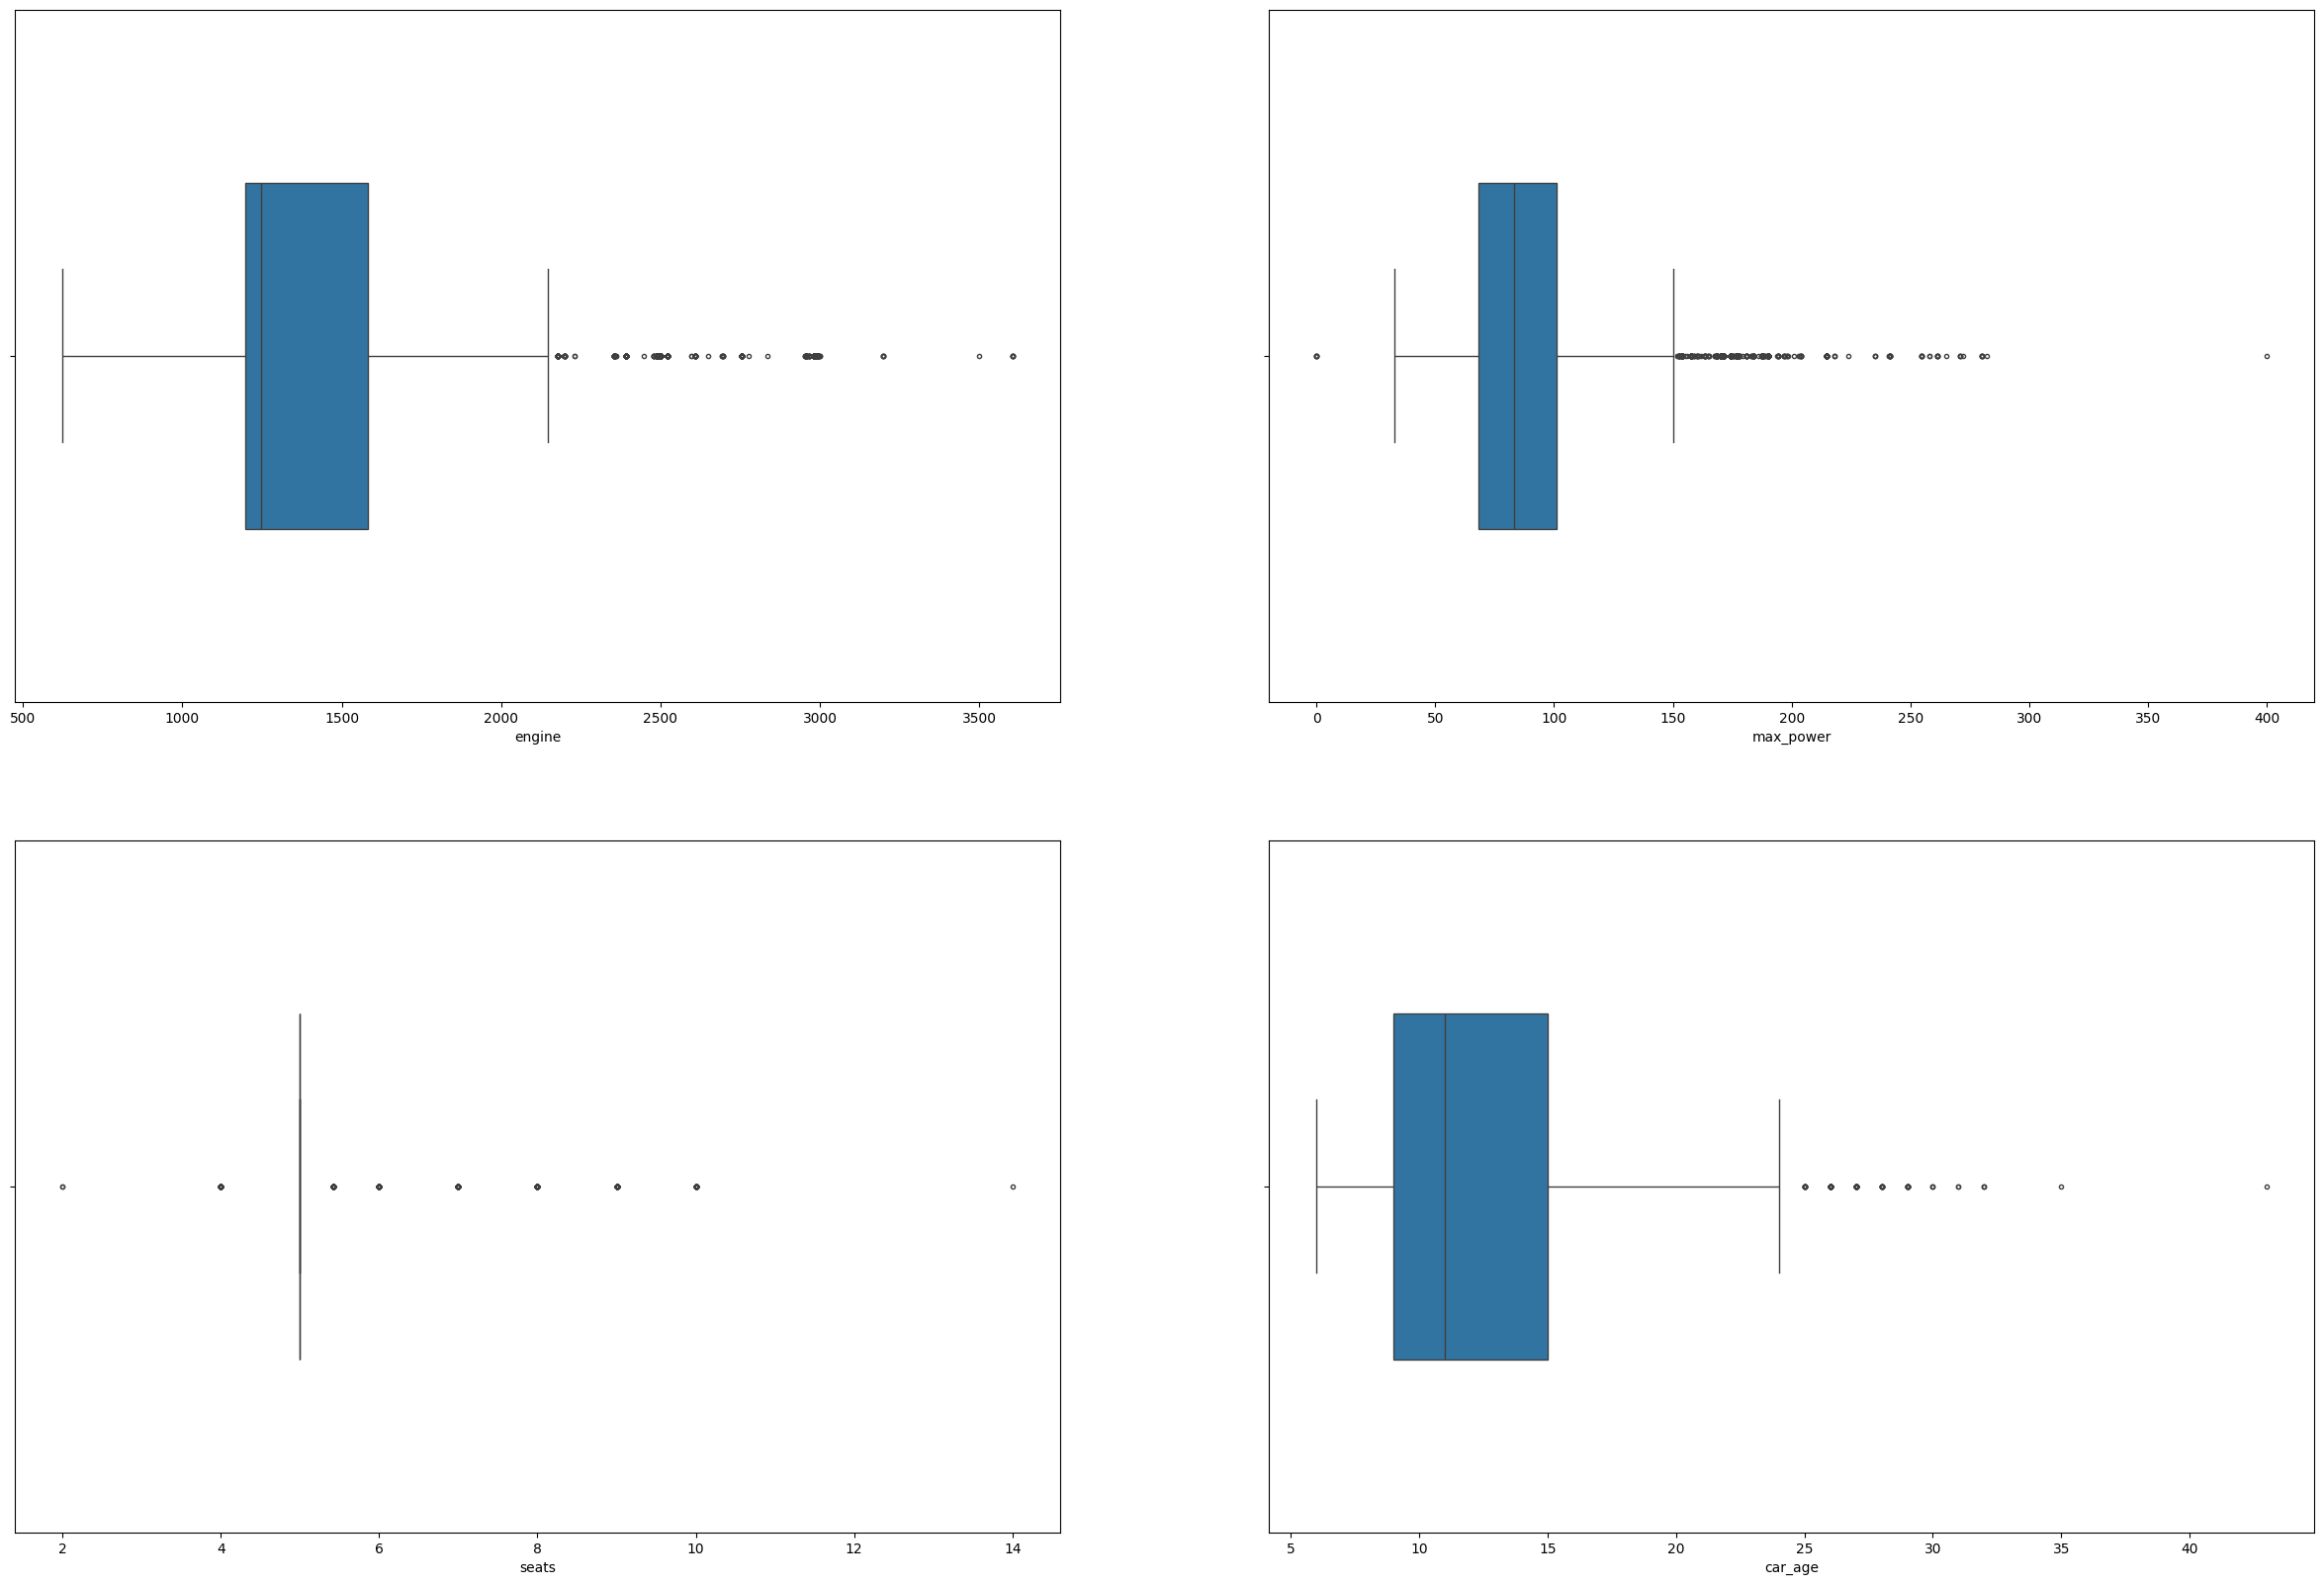

In [27]:
fig, axes = plt.subplots(2, 2, figsize = (30, 20))
axes = axes.flatten()
sns.boxplot(ax=axes[0], x="engine", data=df, width=0.5, fliersize=3, linewidth=1);
sns.boxplot(ax=axes[1], x="max_power", data=df, width=0.5, fliersize=3, linewidth=1);
sns.boxplot(ax=axes[2], x="seats", data=df, width=0.5, fliersize=3, linewidth=1);
sns.boxplot(ax=axes[3], x="car_age", data=df, width=0.5, fliersize=3, linewidth=1);

Histogram

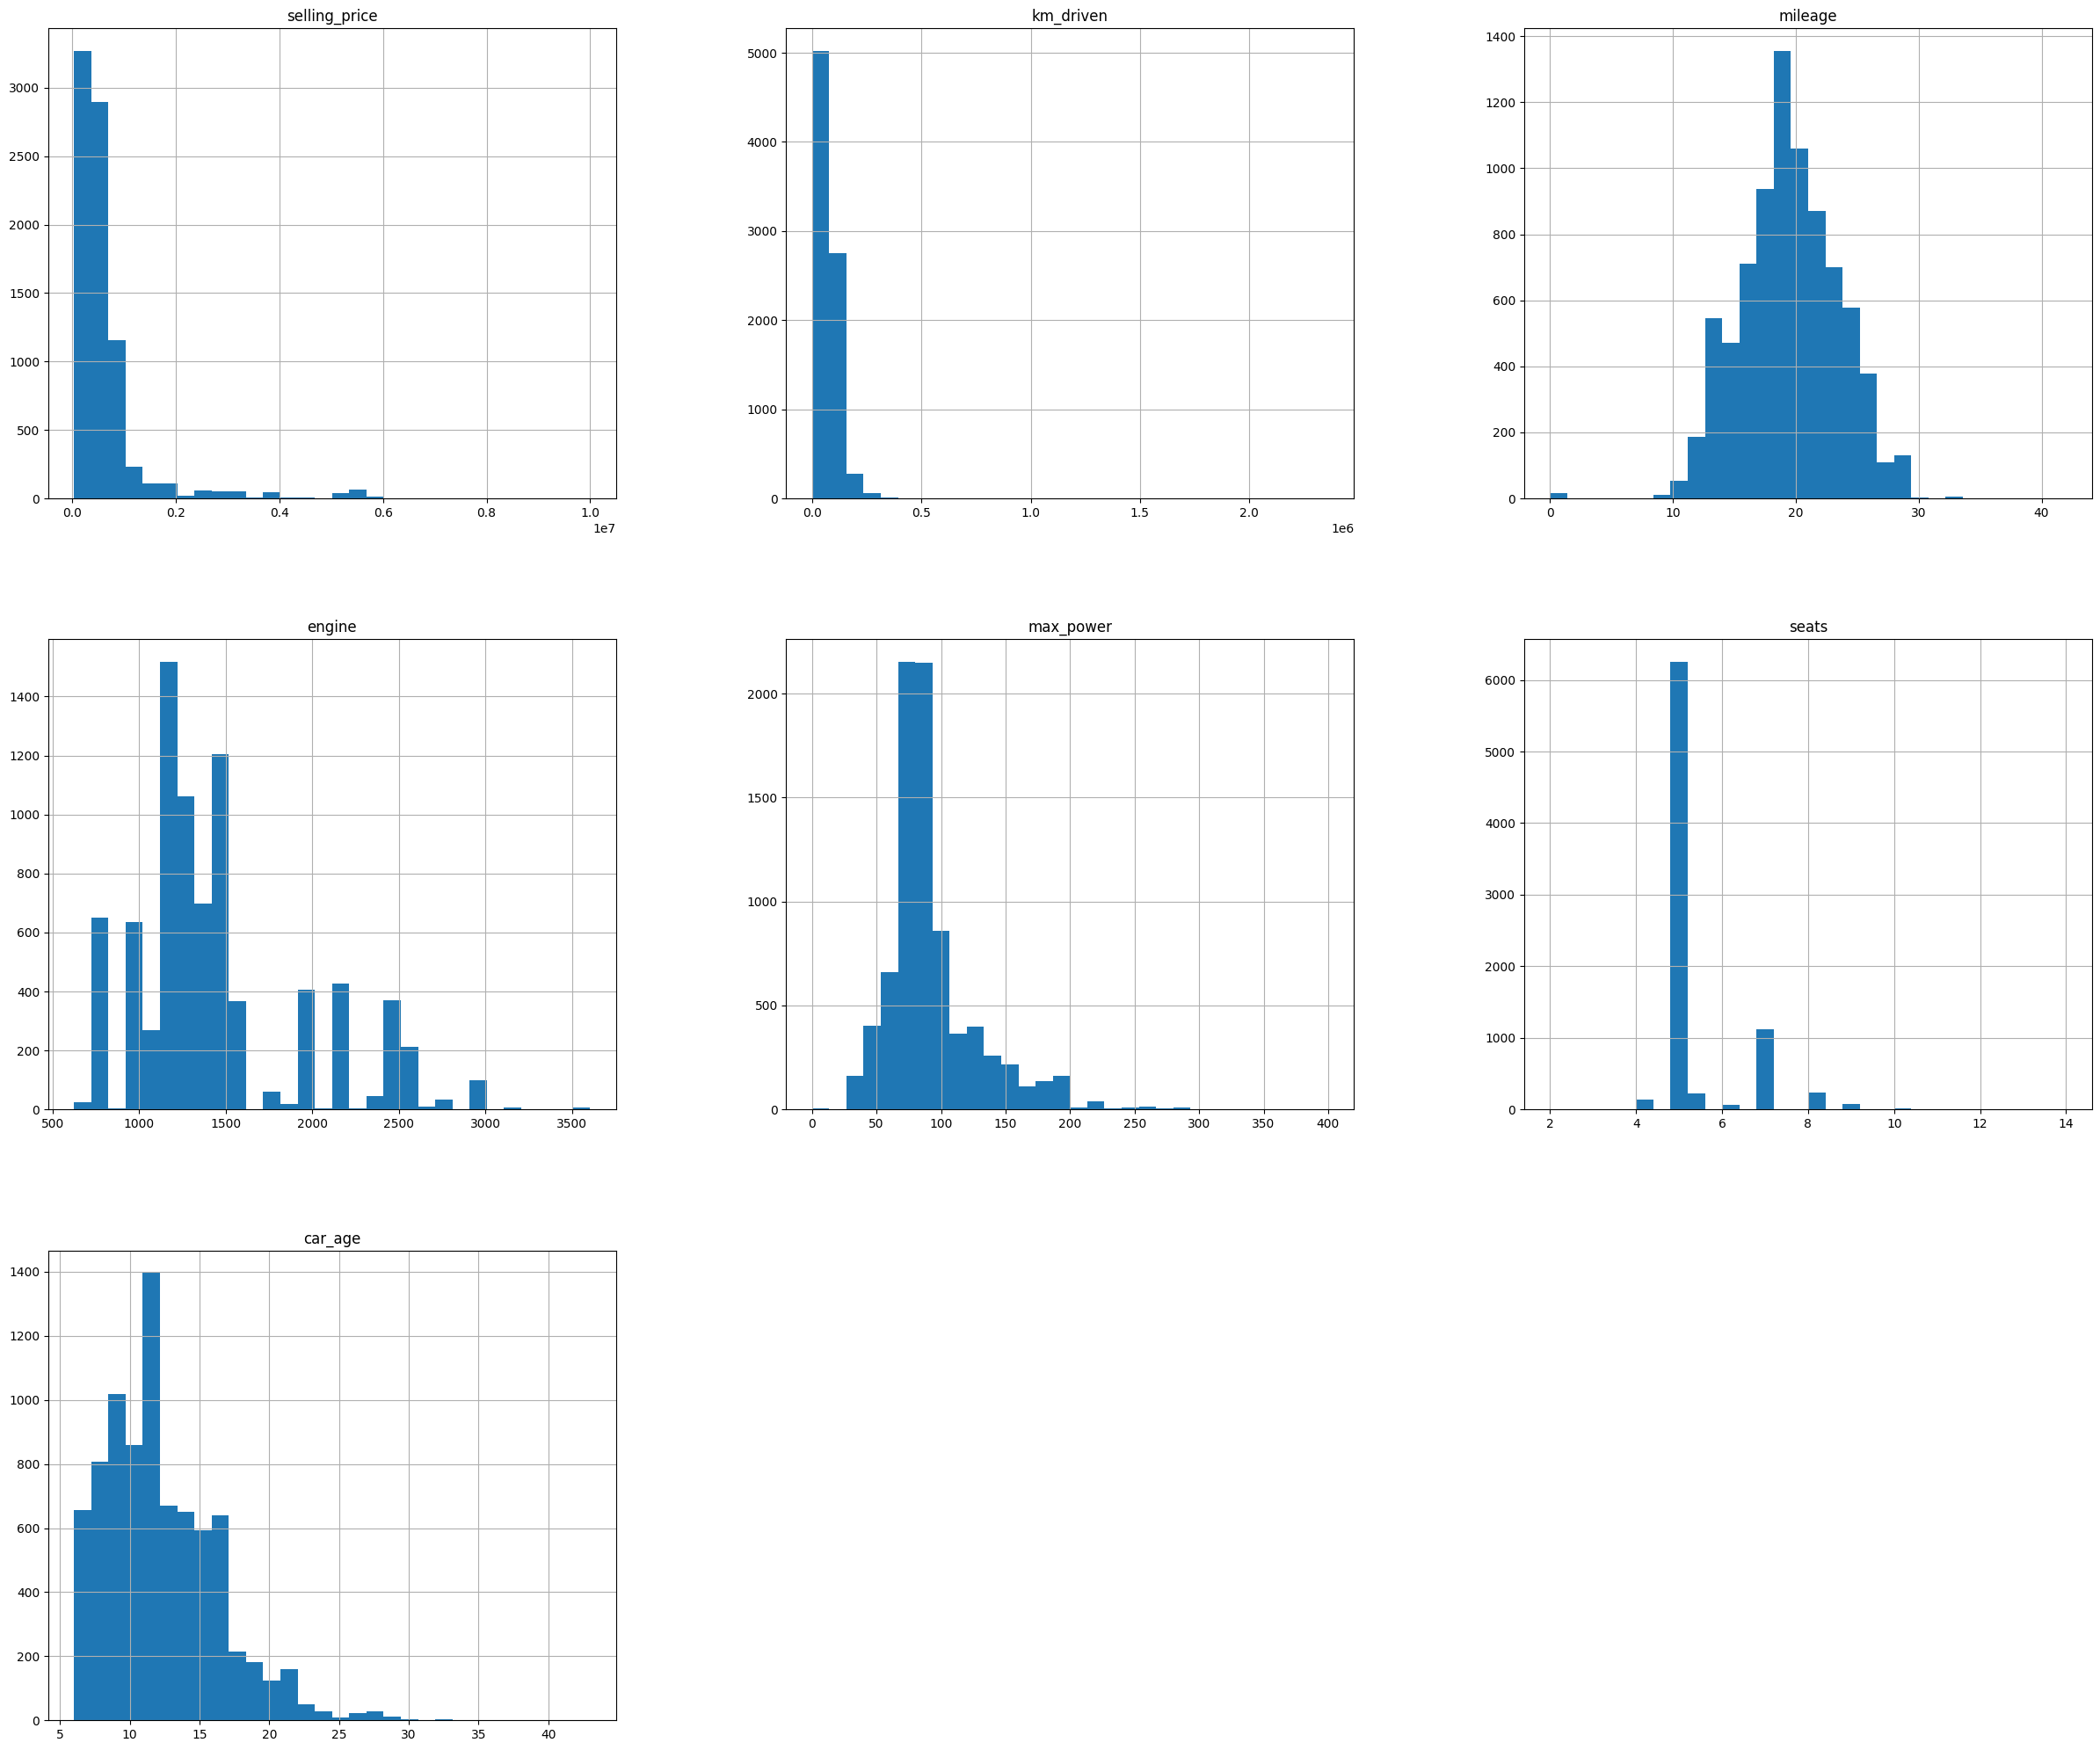

In [28]:
df.hist(figsize=(30, 25), bins=30, legend=False)
plt.show()

As it can be seen from the graphs above, the distributions of the variables (except 'mileage' variable) are not normal.

Catplot

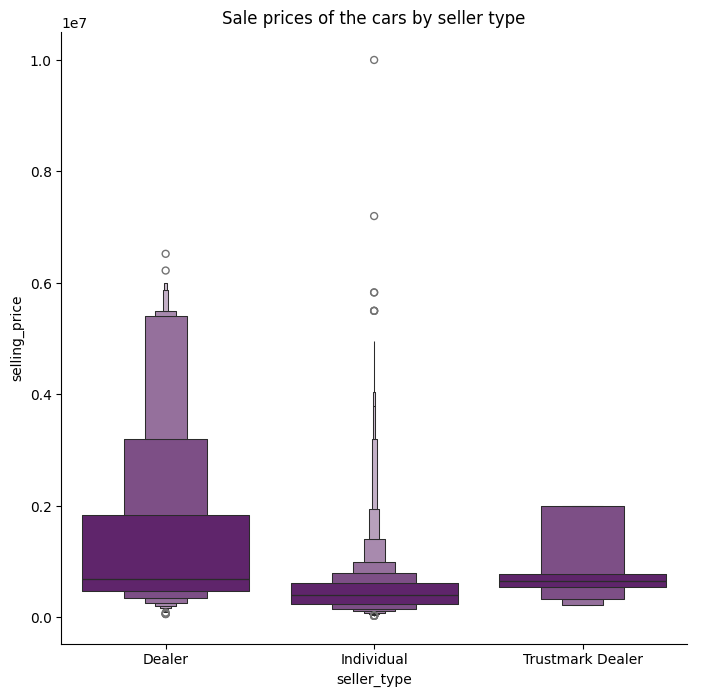

In [29]:
sns.catplot(x = "seller_type",
            y = "selling_price",
            kind = "boxen",
            height = 7,
            aspect = 1,
            color = "#671A76",
            data = df).set(title = "Sale prices of the cars by seller type");

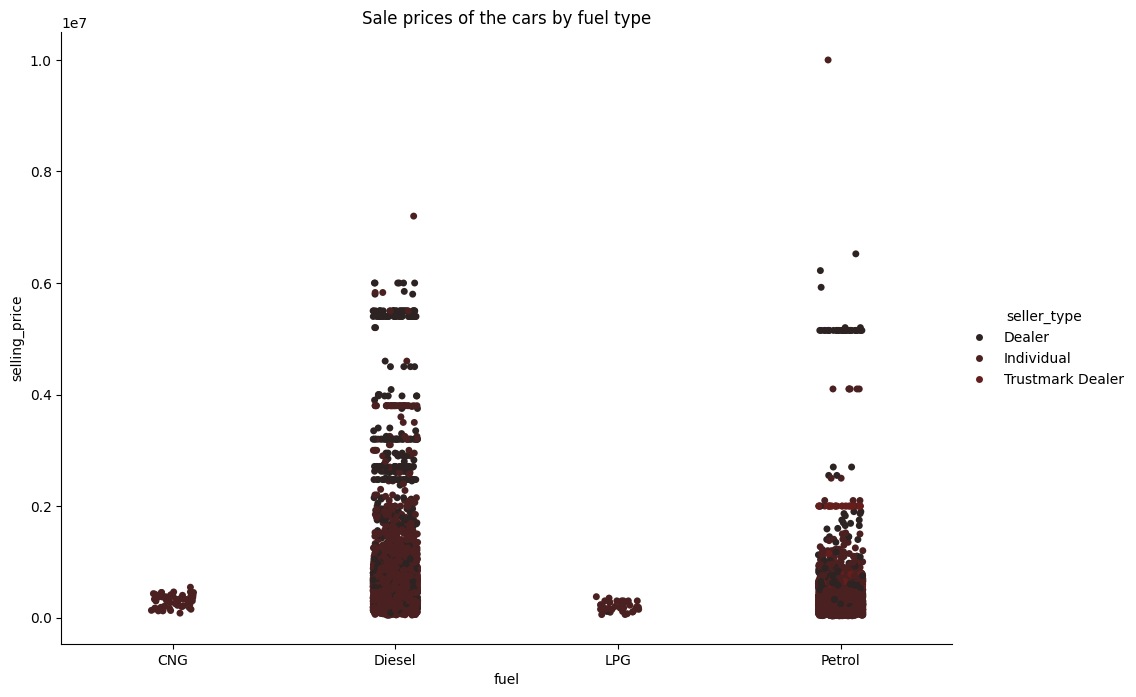

In [30]:
sns.catplot(x = "fuel",
            y = "selling_price",
            kind = "strip",
            hue = "seller_type",
            height = 7,
            aspect = 1.4,
            color = "#661E1D",
            data = df).set(title = "Sale prices of the cars by fuel type");

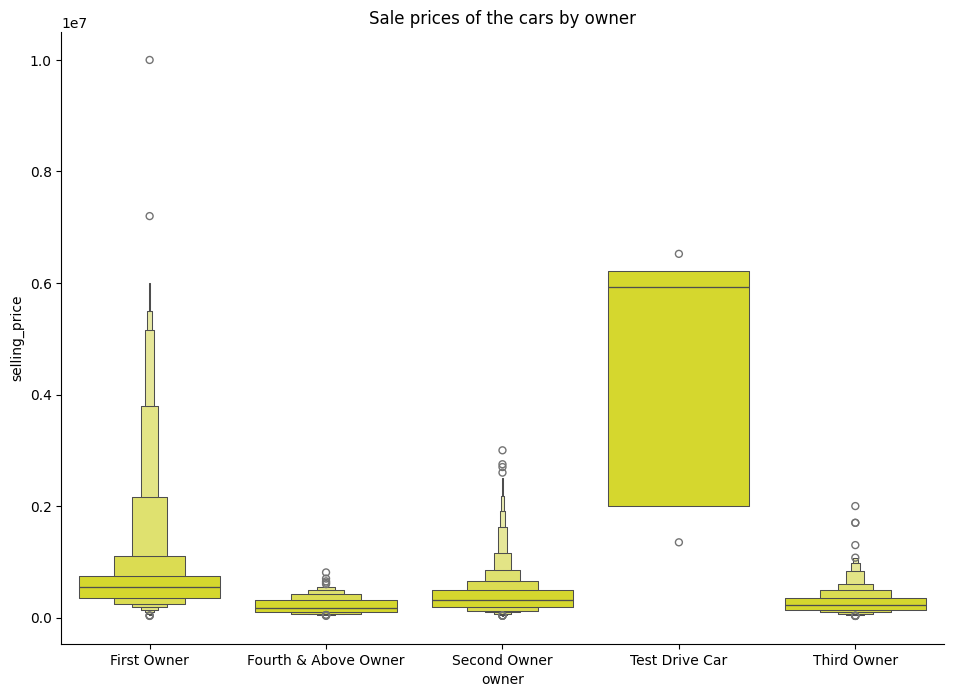

In [31]:
sns.catplot(x = "owner",
            y = "selling_price",
            kind = "boxen",
            height = 7,
            aspect = 1.37,
            color = "#F0F312",
            data = df).set(title = "Sale prices of the cars by owner");

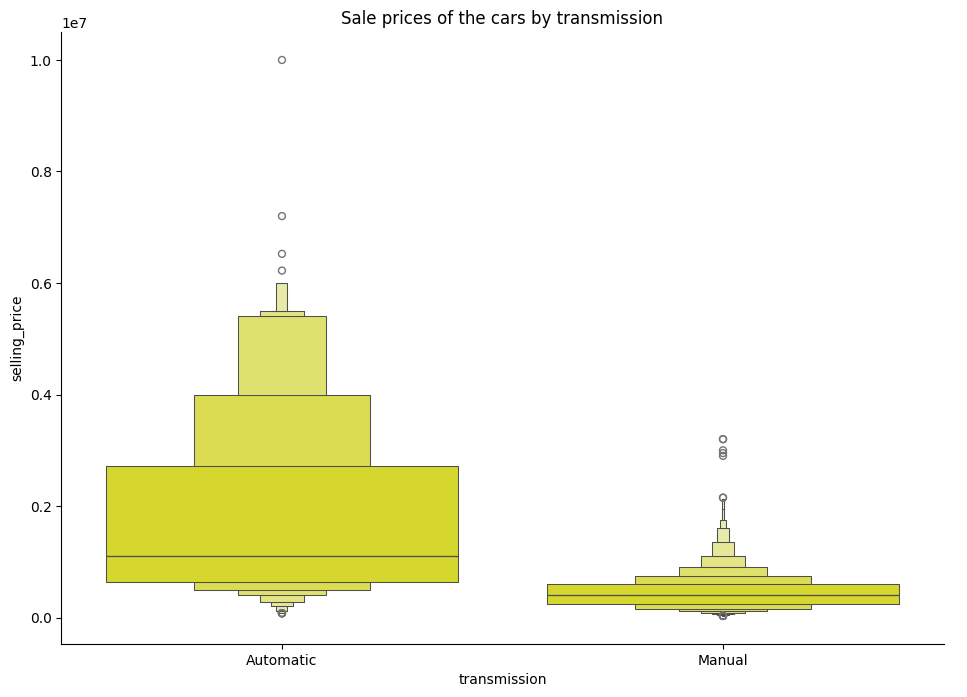

In [32]:
sns.catplot(x = "transmission",
            y = "selling_price",
            kind = "boxen",
            height = 7,
            aspect = 1.37,
            color = "#F0F312",
            data = df).set(title = "Sale prices of the cars by transmission");

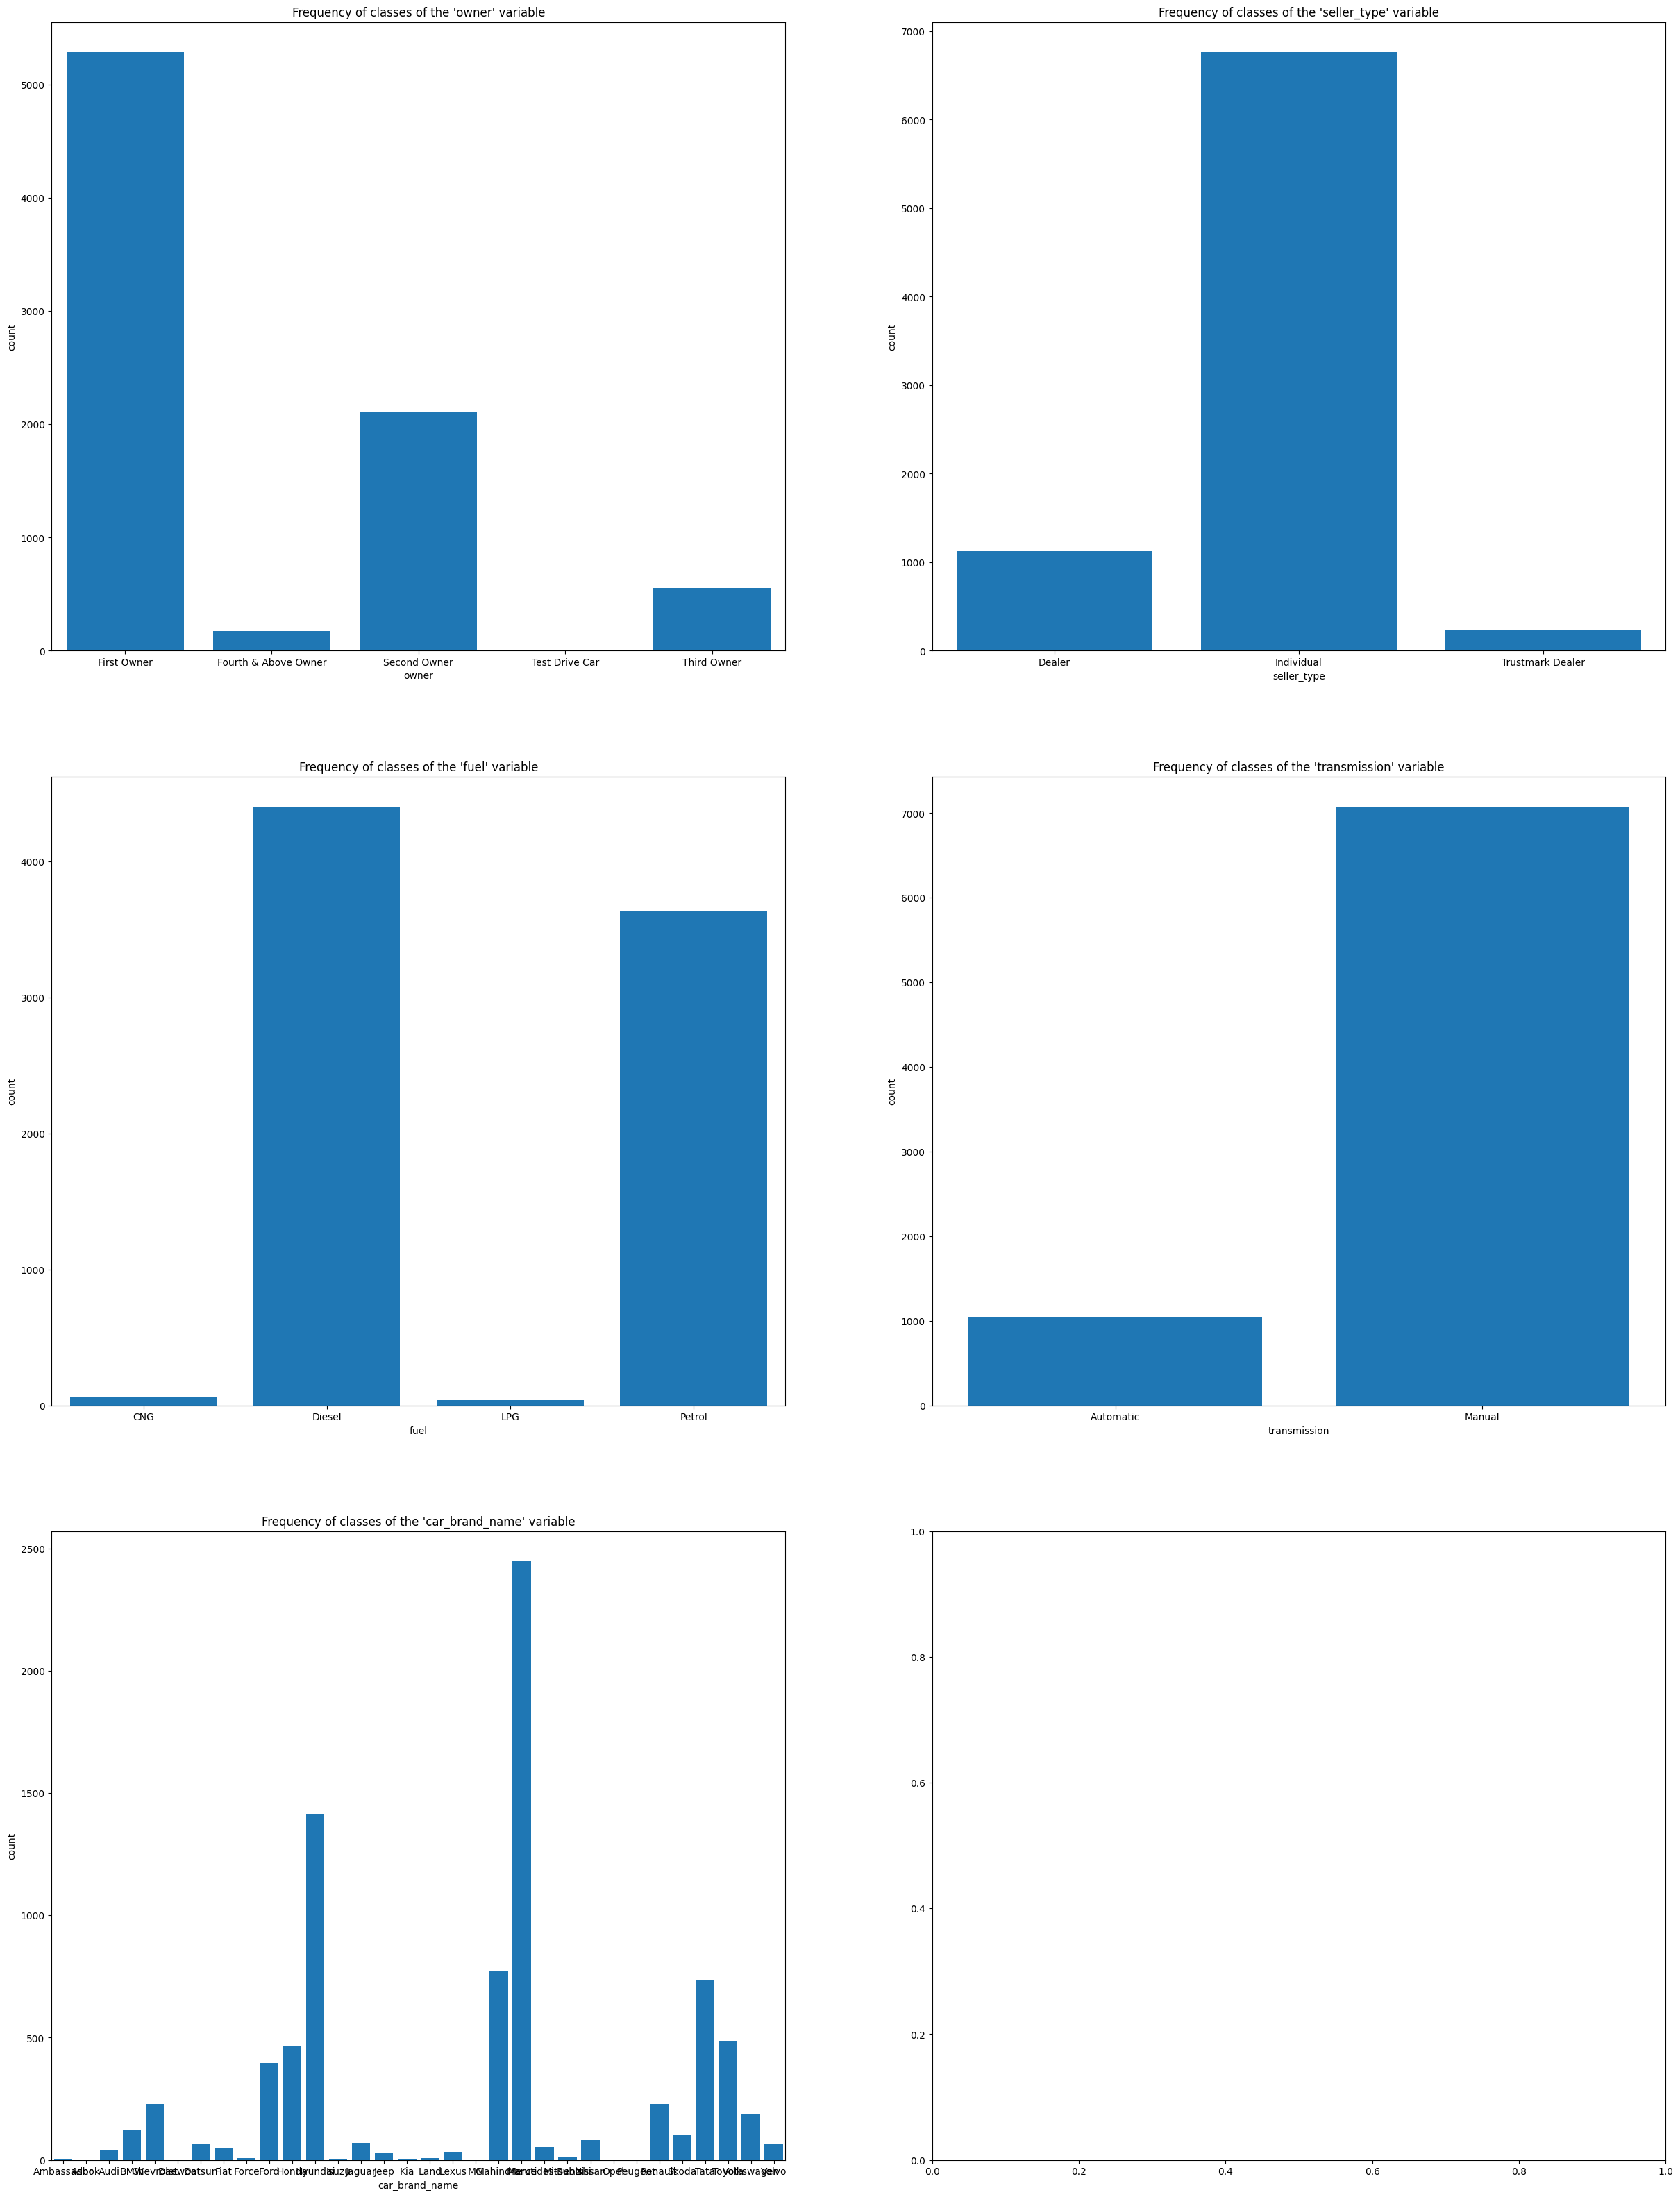

In [33]:
fig, axes = plt.subplots(3, 2, figsize = (30, 40))
axes = axes.flatten()

sns.barplot(ax = axes[0], x = df["owner"].value_counts().index, y = df["owner"].value_counts(),
            saturation = 1).set(title = "Frequency of classes of the 'owner' variable");

sns.barplot(ax = axes[1], x = df["seller_type"].value_counts().index, y = df["seller_type"].value_counts(),
            saturation = 1).set(title = "Frequency of classes of the 'seller_type' variable");

sns.barplot(ax = axes[2], x = df["fuel"].value_counts().index, y = df["fuel"].value_counts(),
            saturation = 1).set(title = "Frequency of classes of the 'fuel' variable");

sns.barplot(ax = axes[3], x = df["transmission"].value_counts().index, y = df["transmission"].value_counts(),
            saturation = 1).set(title = "Frequency of classes of the 'transmission' variable");

sns.barplot(ax = axes[4], x = df["car_brand_name"].value_counts().index, y = df["car_brand_name"].value_counts(),
            saturation = 1).set(title = "Frequency of classes of the 'car_brand_name' variable");

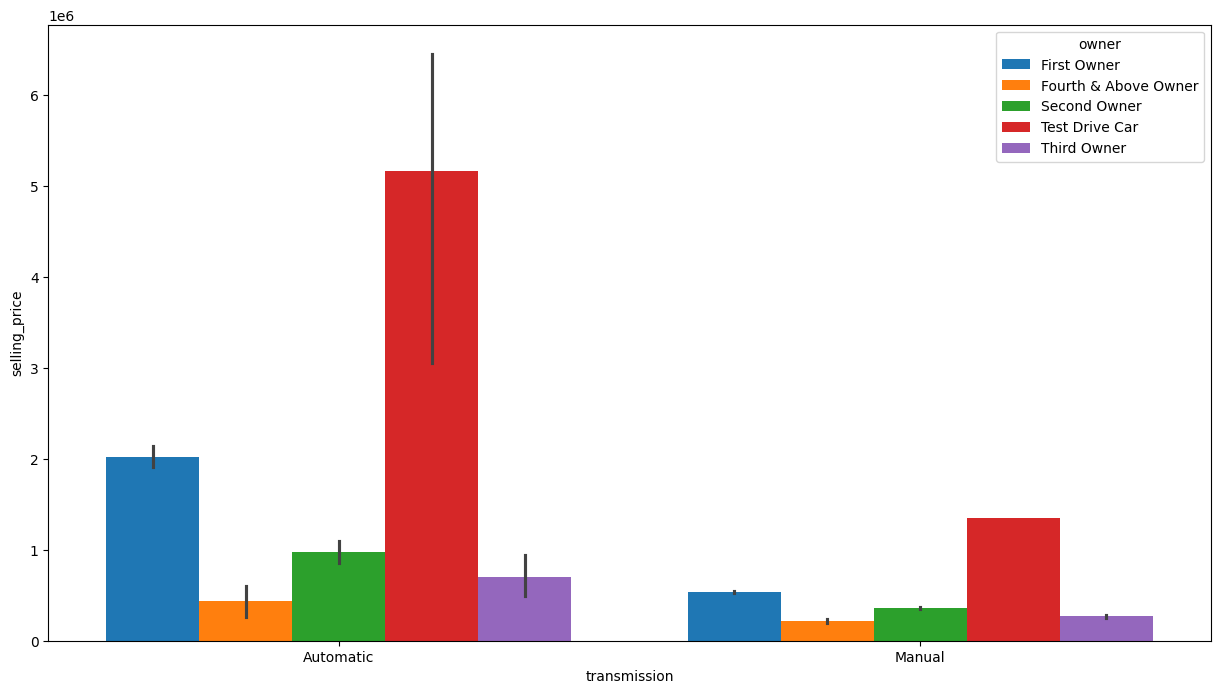

In [34]:
plt.figure(figsize = (15, 8))
sns.barplot(x = "transmission", y = "selling_price", hue = "owner", data = df, saturation = 1);

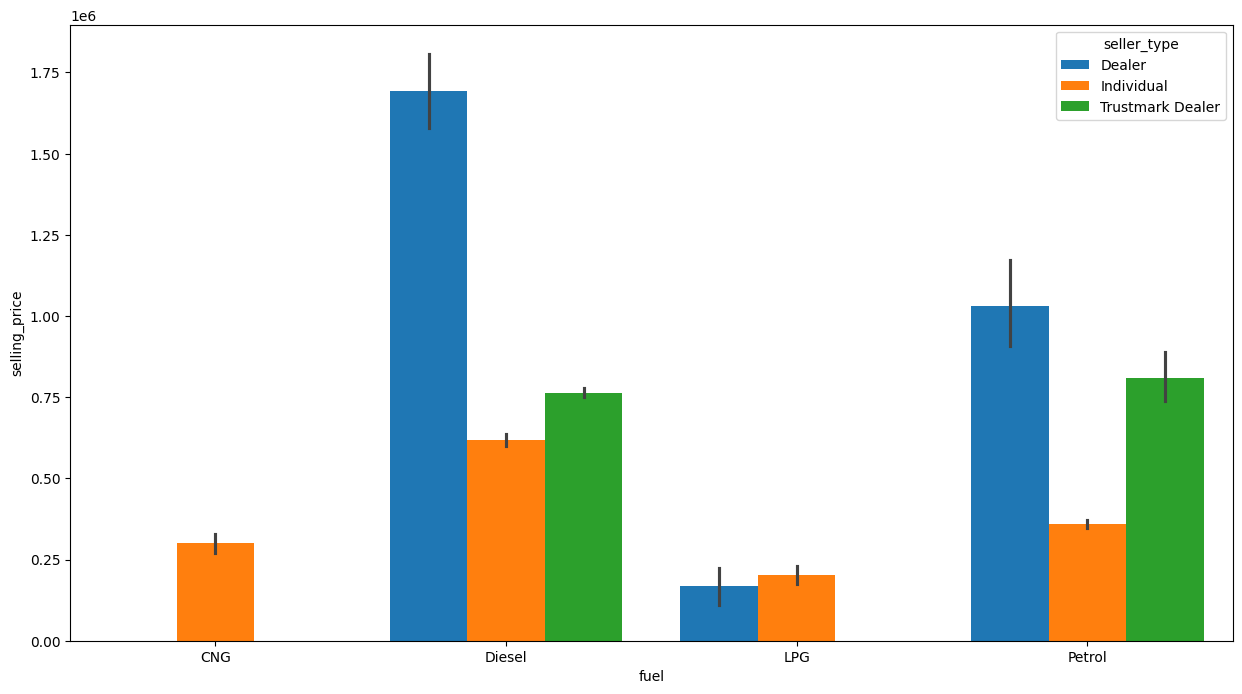

In [35]:
plt.figure(figsize = (15, 8))
sns.barplot(x = "fuel", y = "selling_price", hue = "seller_type", data = df, saturation = 1);

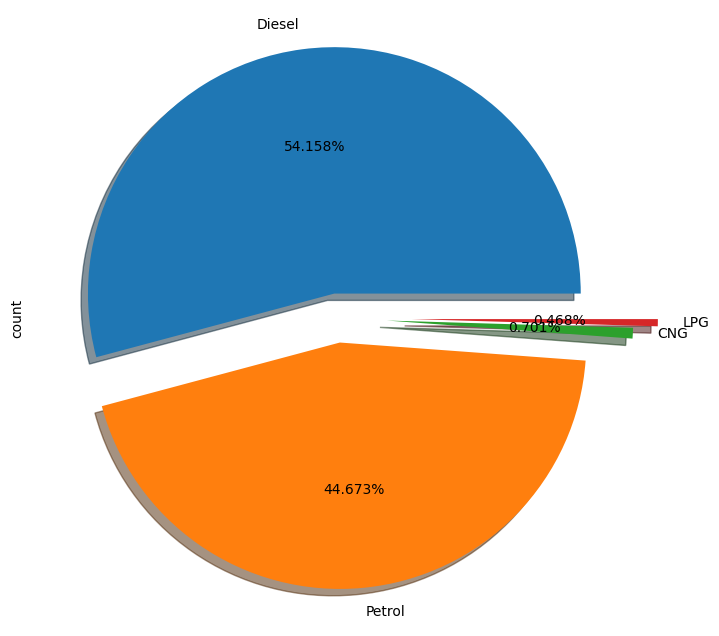

In [36]:
plt.figure(figsize = [8, 8], clear = True, facecolor = "#FFFFFF")
df["fuel"].value_counts().plot.pie(explode = [0.1, 0.1, 0.2, 0.3], autopct='%1.3f%%', shadow = True);

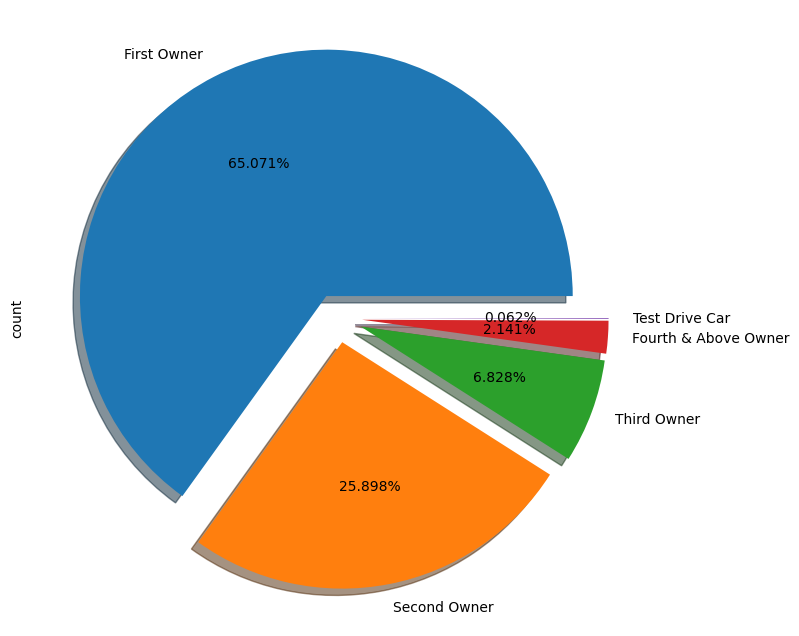

In [37]:
plt.figure(figsize = [8, 8], clear = True, facecolor = "#FFFFFF")
df["owner"].value_counts().plot.pie(explode = [0.1, 0.1, 0.1, 0.1, 0.1], autopct='%1.3f%%', shadow = True);

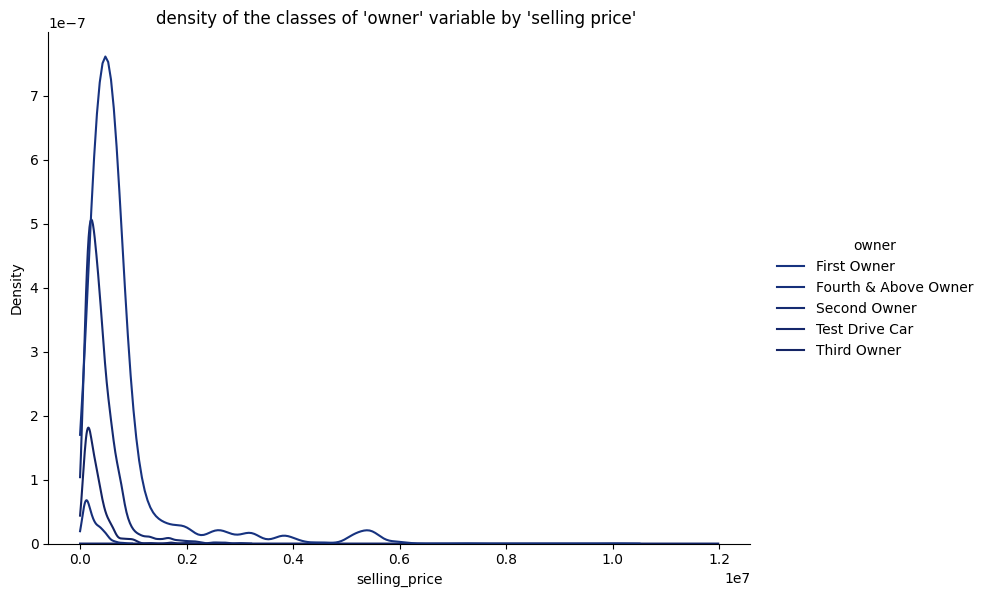

In [38]:
sns.displot(data = df, x = "selling_price", hue = "owner", kind = "kde", height = 6,
            aspect = 1.3, clip=(0, None), palette="ch:rot=-.25, hue = 2, light=.20"
).set(title = "density of the classes of 'owner' variable by 'selling price' ");

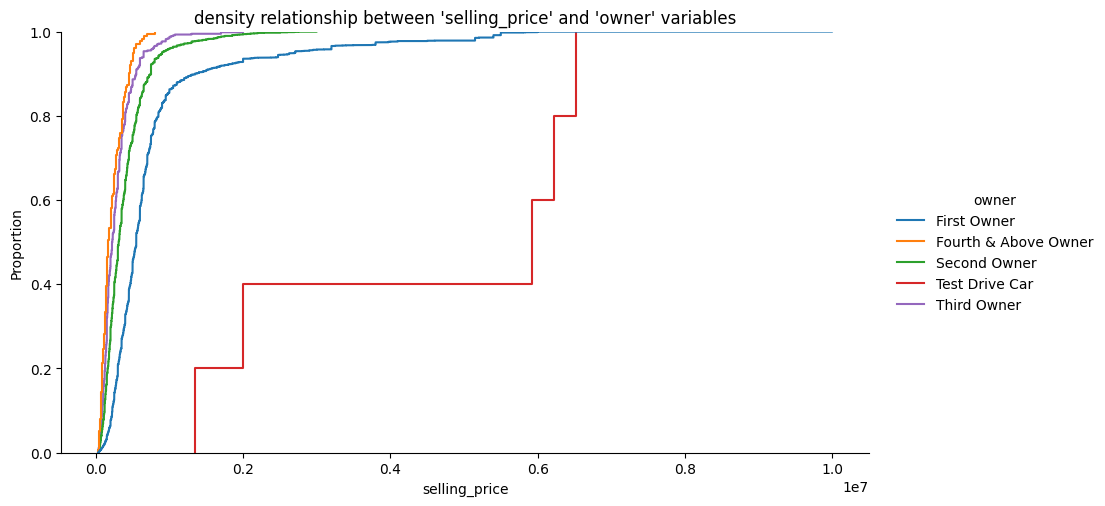

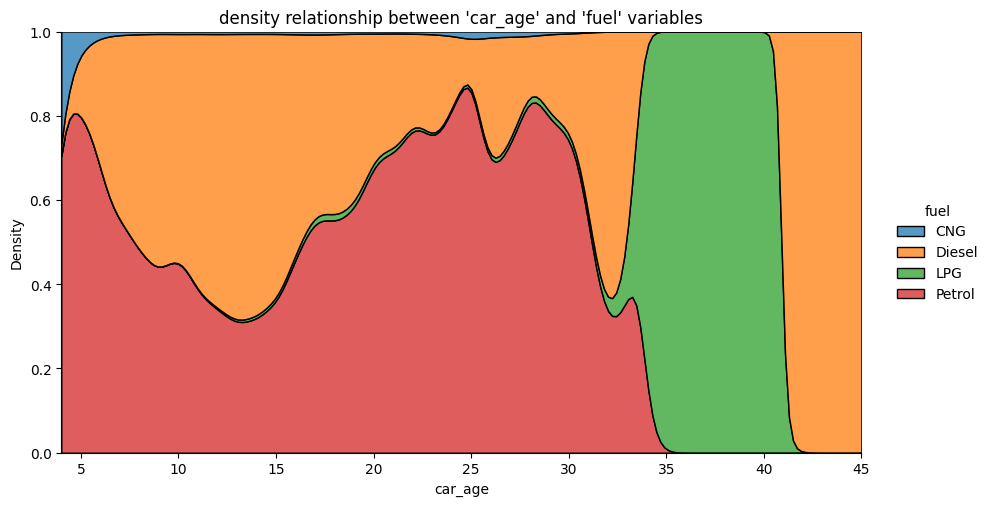

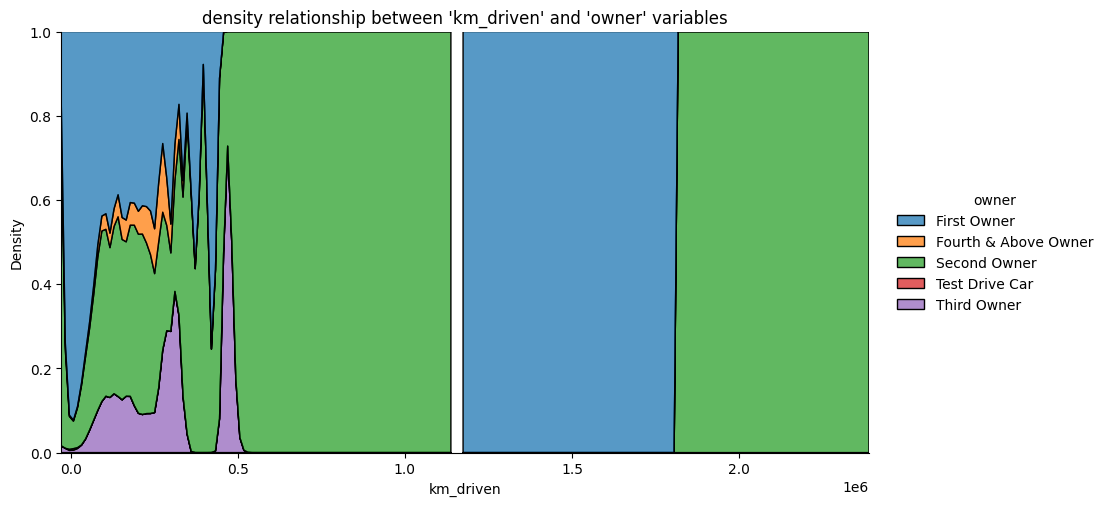

In [39]:
sns.displot(data = df, x = "selling_price", hue = "owner",
    kind = "ecdf", height = 5, aspect = 1.8).set(title =  "density relationship between 'selling_price' and 'owner' variables");

sns.displot(
    data = df, x = "car_age", hue = "fuel",
    kind = "kde", height = 5, aspect = 1.8, multiple="fill").set(title = "density relationship between 'car_age' and 'fuel' variables");

sns.displot(
    data = df, x = "km_driven", hue = "owner",
    kind = "kde", height = 5, aspect = 1.8, multiple="fill").set(title = "density relationship between 'km_driven' and 'owner' variables");

plotly express

In [40]:
import plotly.express as px
import plotly.io as pio

fig = px.histogram(df, x = "car_age", y = "selling_price", marginal = None, text_auto = True,
                   color = "owner", hover_data  = df.columns, width = 850, height = 500)
fig.show()

In [41]:

fig = px.histogram(df, x = "engine", y = "km_driven", marginal = None, text_auto = True,
                   color = "fuel", hover_data  = df.columns, width = 850, height = 500)
fig.show()

In [42]:
fig = px.histogram(df, x = "car_age", y = "km_driven", marginal = None, text_auto = True,
                   color = "owner", hover_data  = df.columns, width = 850, height = 500)
fig.show()

In [43]:
fig = px.density_heatmap(df, x = "max_power", y = "selling_price", z = "mileage",
                        color_continuous_scale = "deep", text_auto = True,
                        title = "Density heatmap between variables")
fig.show()

In [44]:
fig = px.density_heatmap(df, x = "seats", y = "engine", z = "max_power", color_continuous_scale = "portland",
                         text_auto = True, title = "Density heatmap between variables")
fig.show()

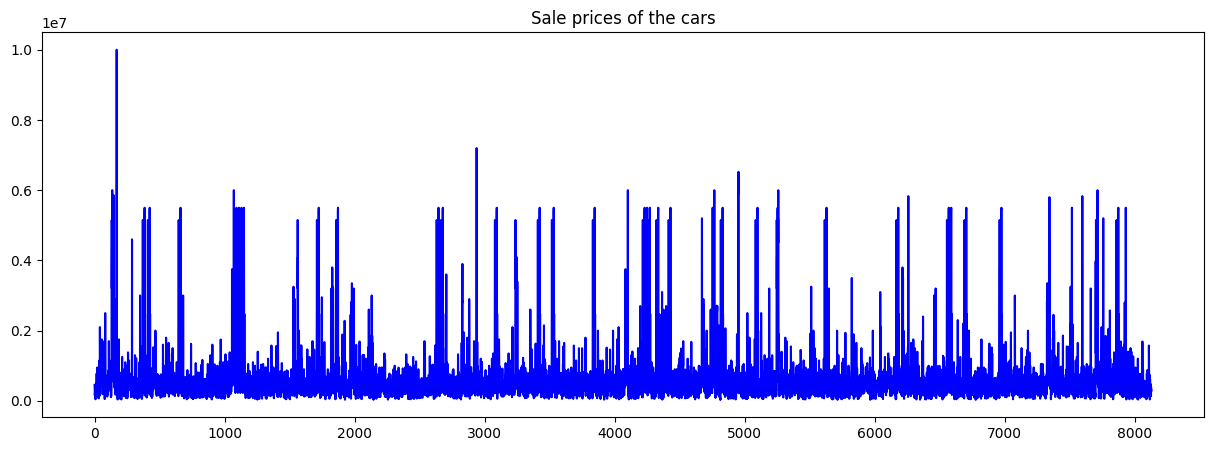

In [45]:
fig, ax = plt.subplots(figsize = (15, 5))
pd.Series(df.selling_price.values).plot(kind = "line", colormap = "winter").set_title("Sale prices of the cars");

Pairplot

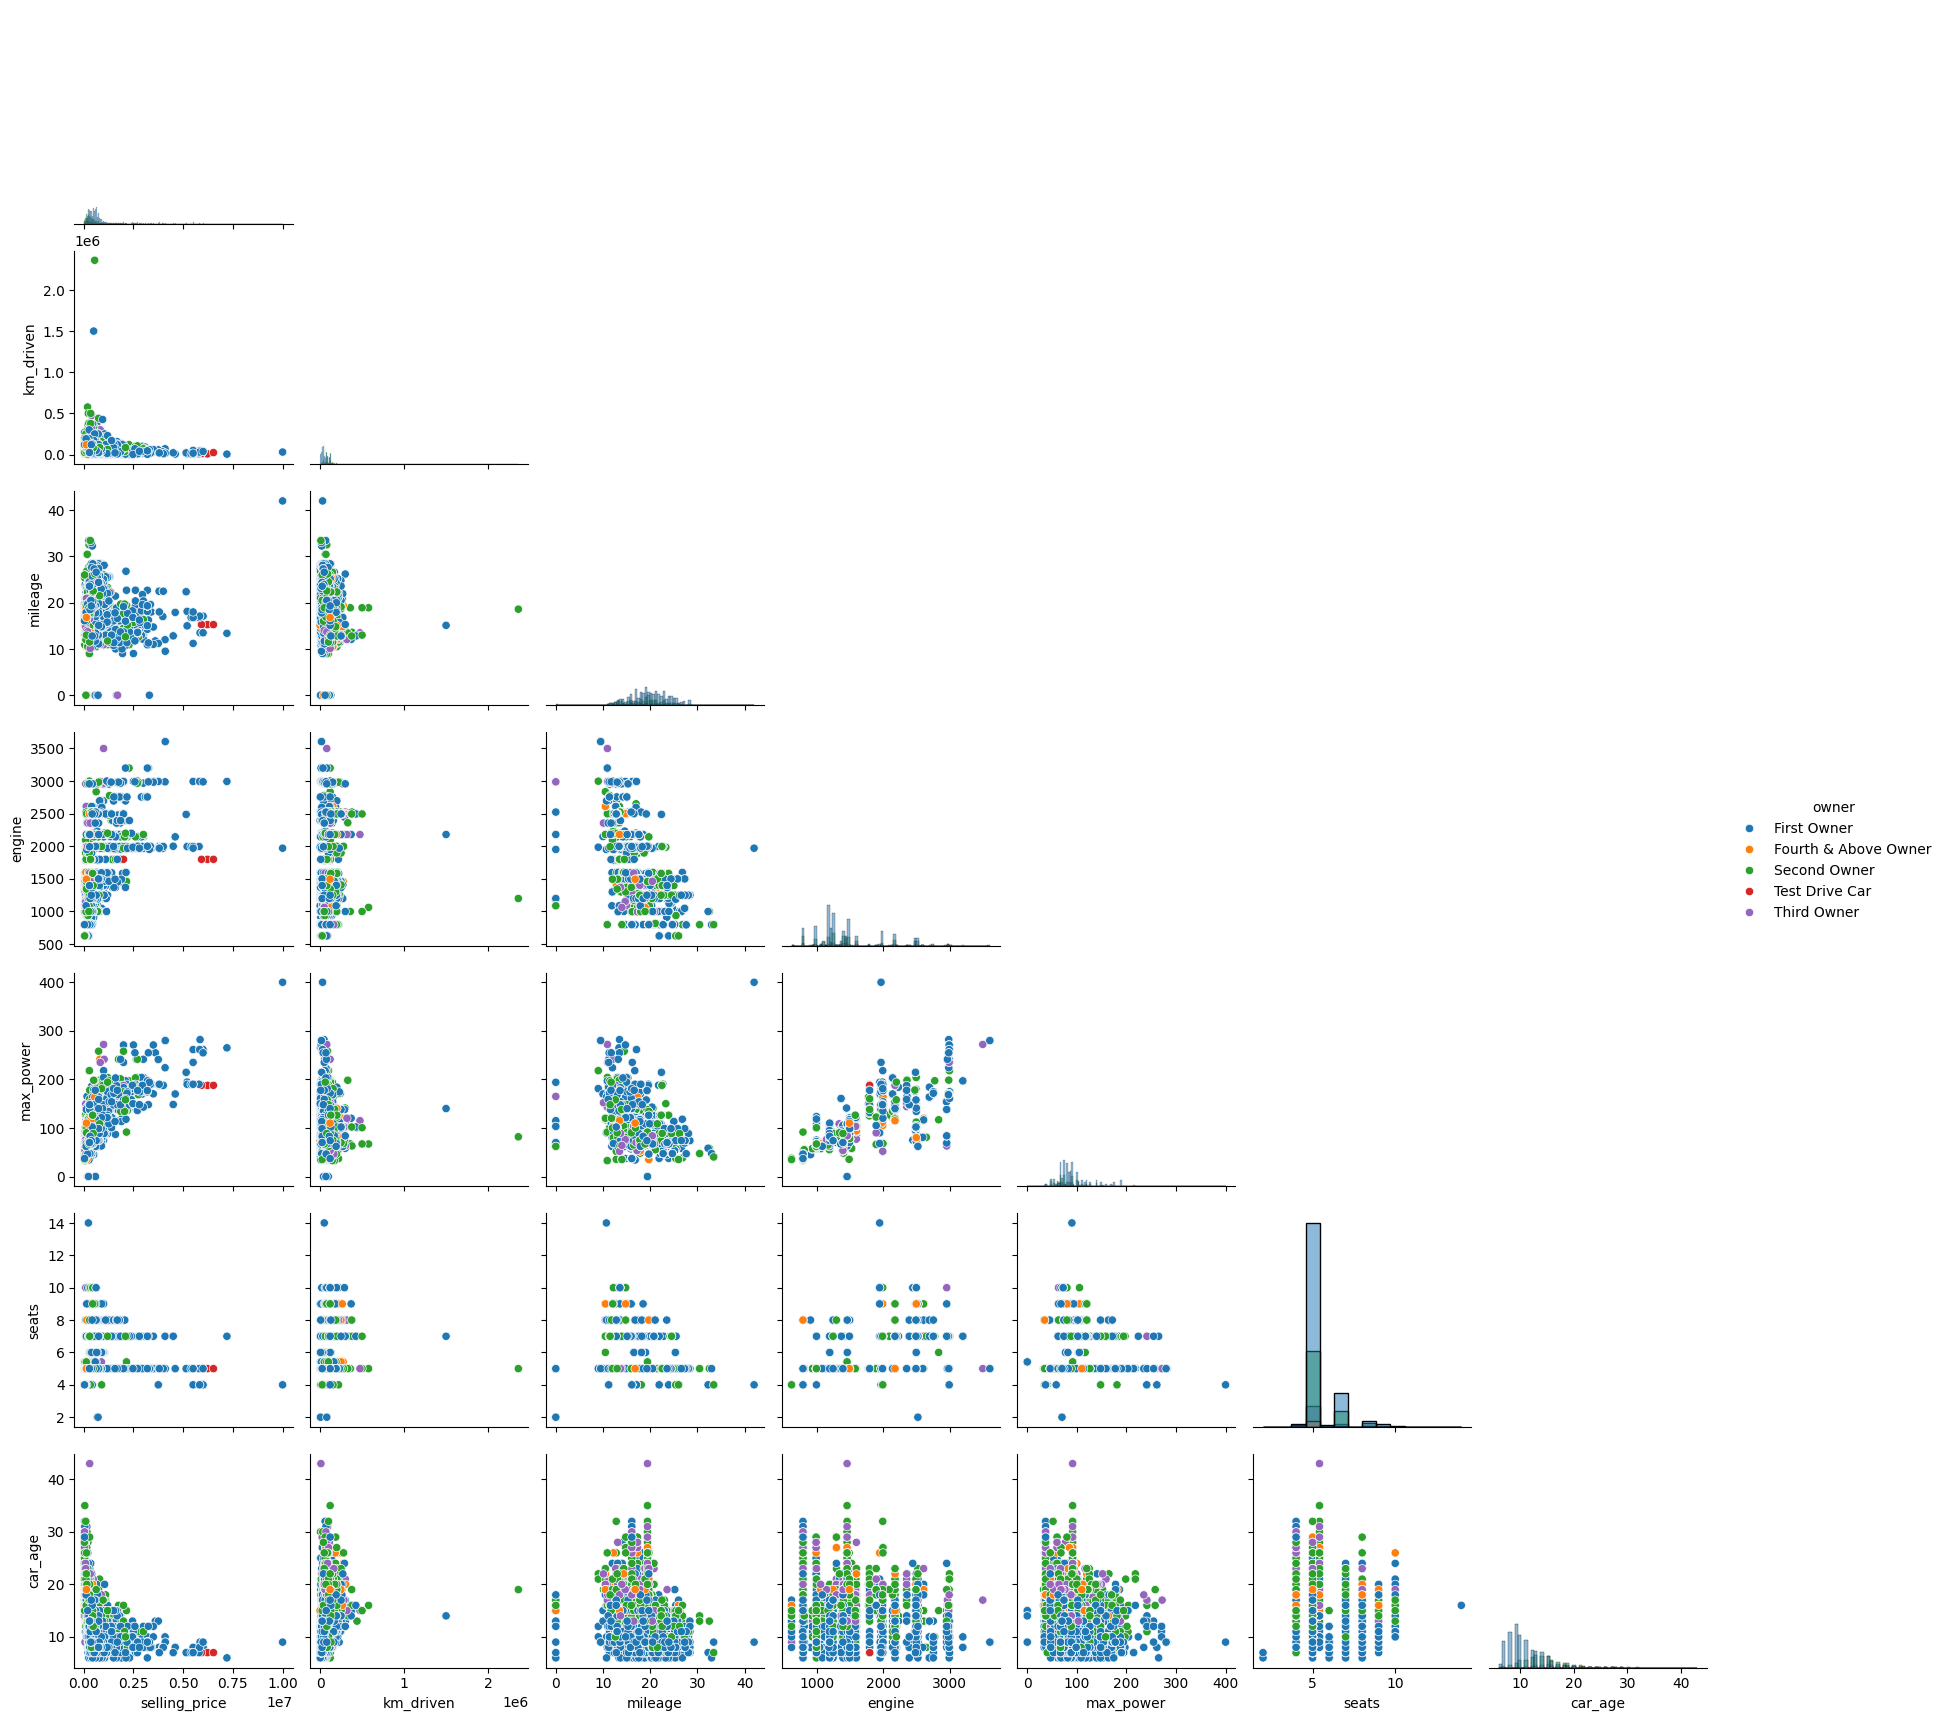

In [46]:
sns.pairplot(df, hue = "owner", diag_kind = "hist", corner = True);

Regplot

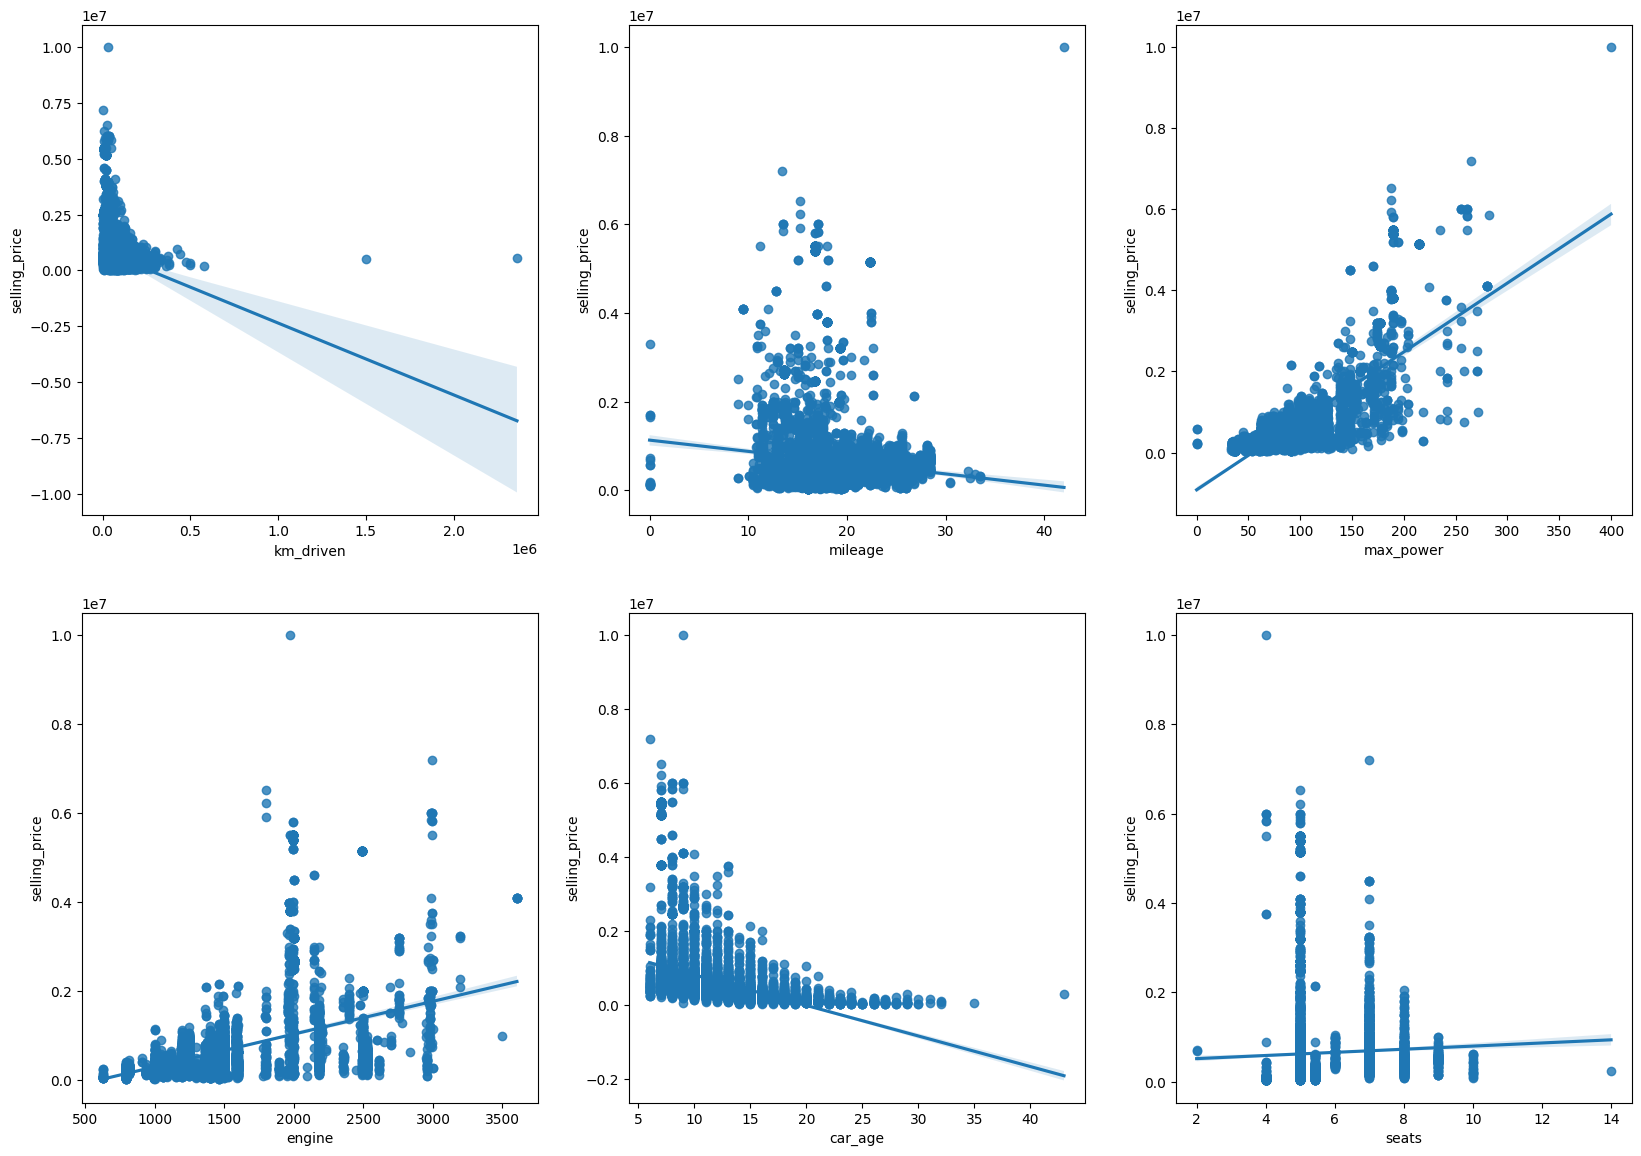

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

sns.regplot(ax = axes[0], x = "km_driven", y = "selling_price", data = df);
sns.regplot(ax = axes[1], x = "mileage", y = "selling_price", data = df);
sns.regplot(ax = axes[2], x = "max_power", y = "selling_price", data = df);
sns.regplot(ax = axes[3], x = "engine", y = "selling_price", data = df);
sns.regplot(ax = axes[4], x = "car_age", y = "selling_price", data = df);
sns.regplot(ax = axes[5], x = "seats", y = "selling_price", data = df);

Correlation and Heatmap

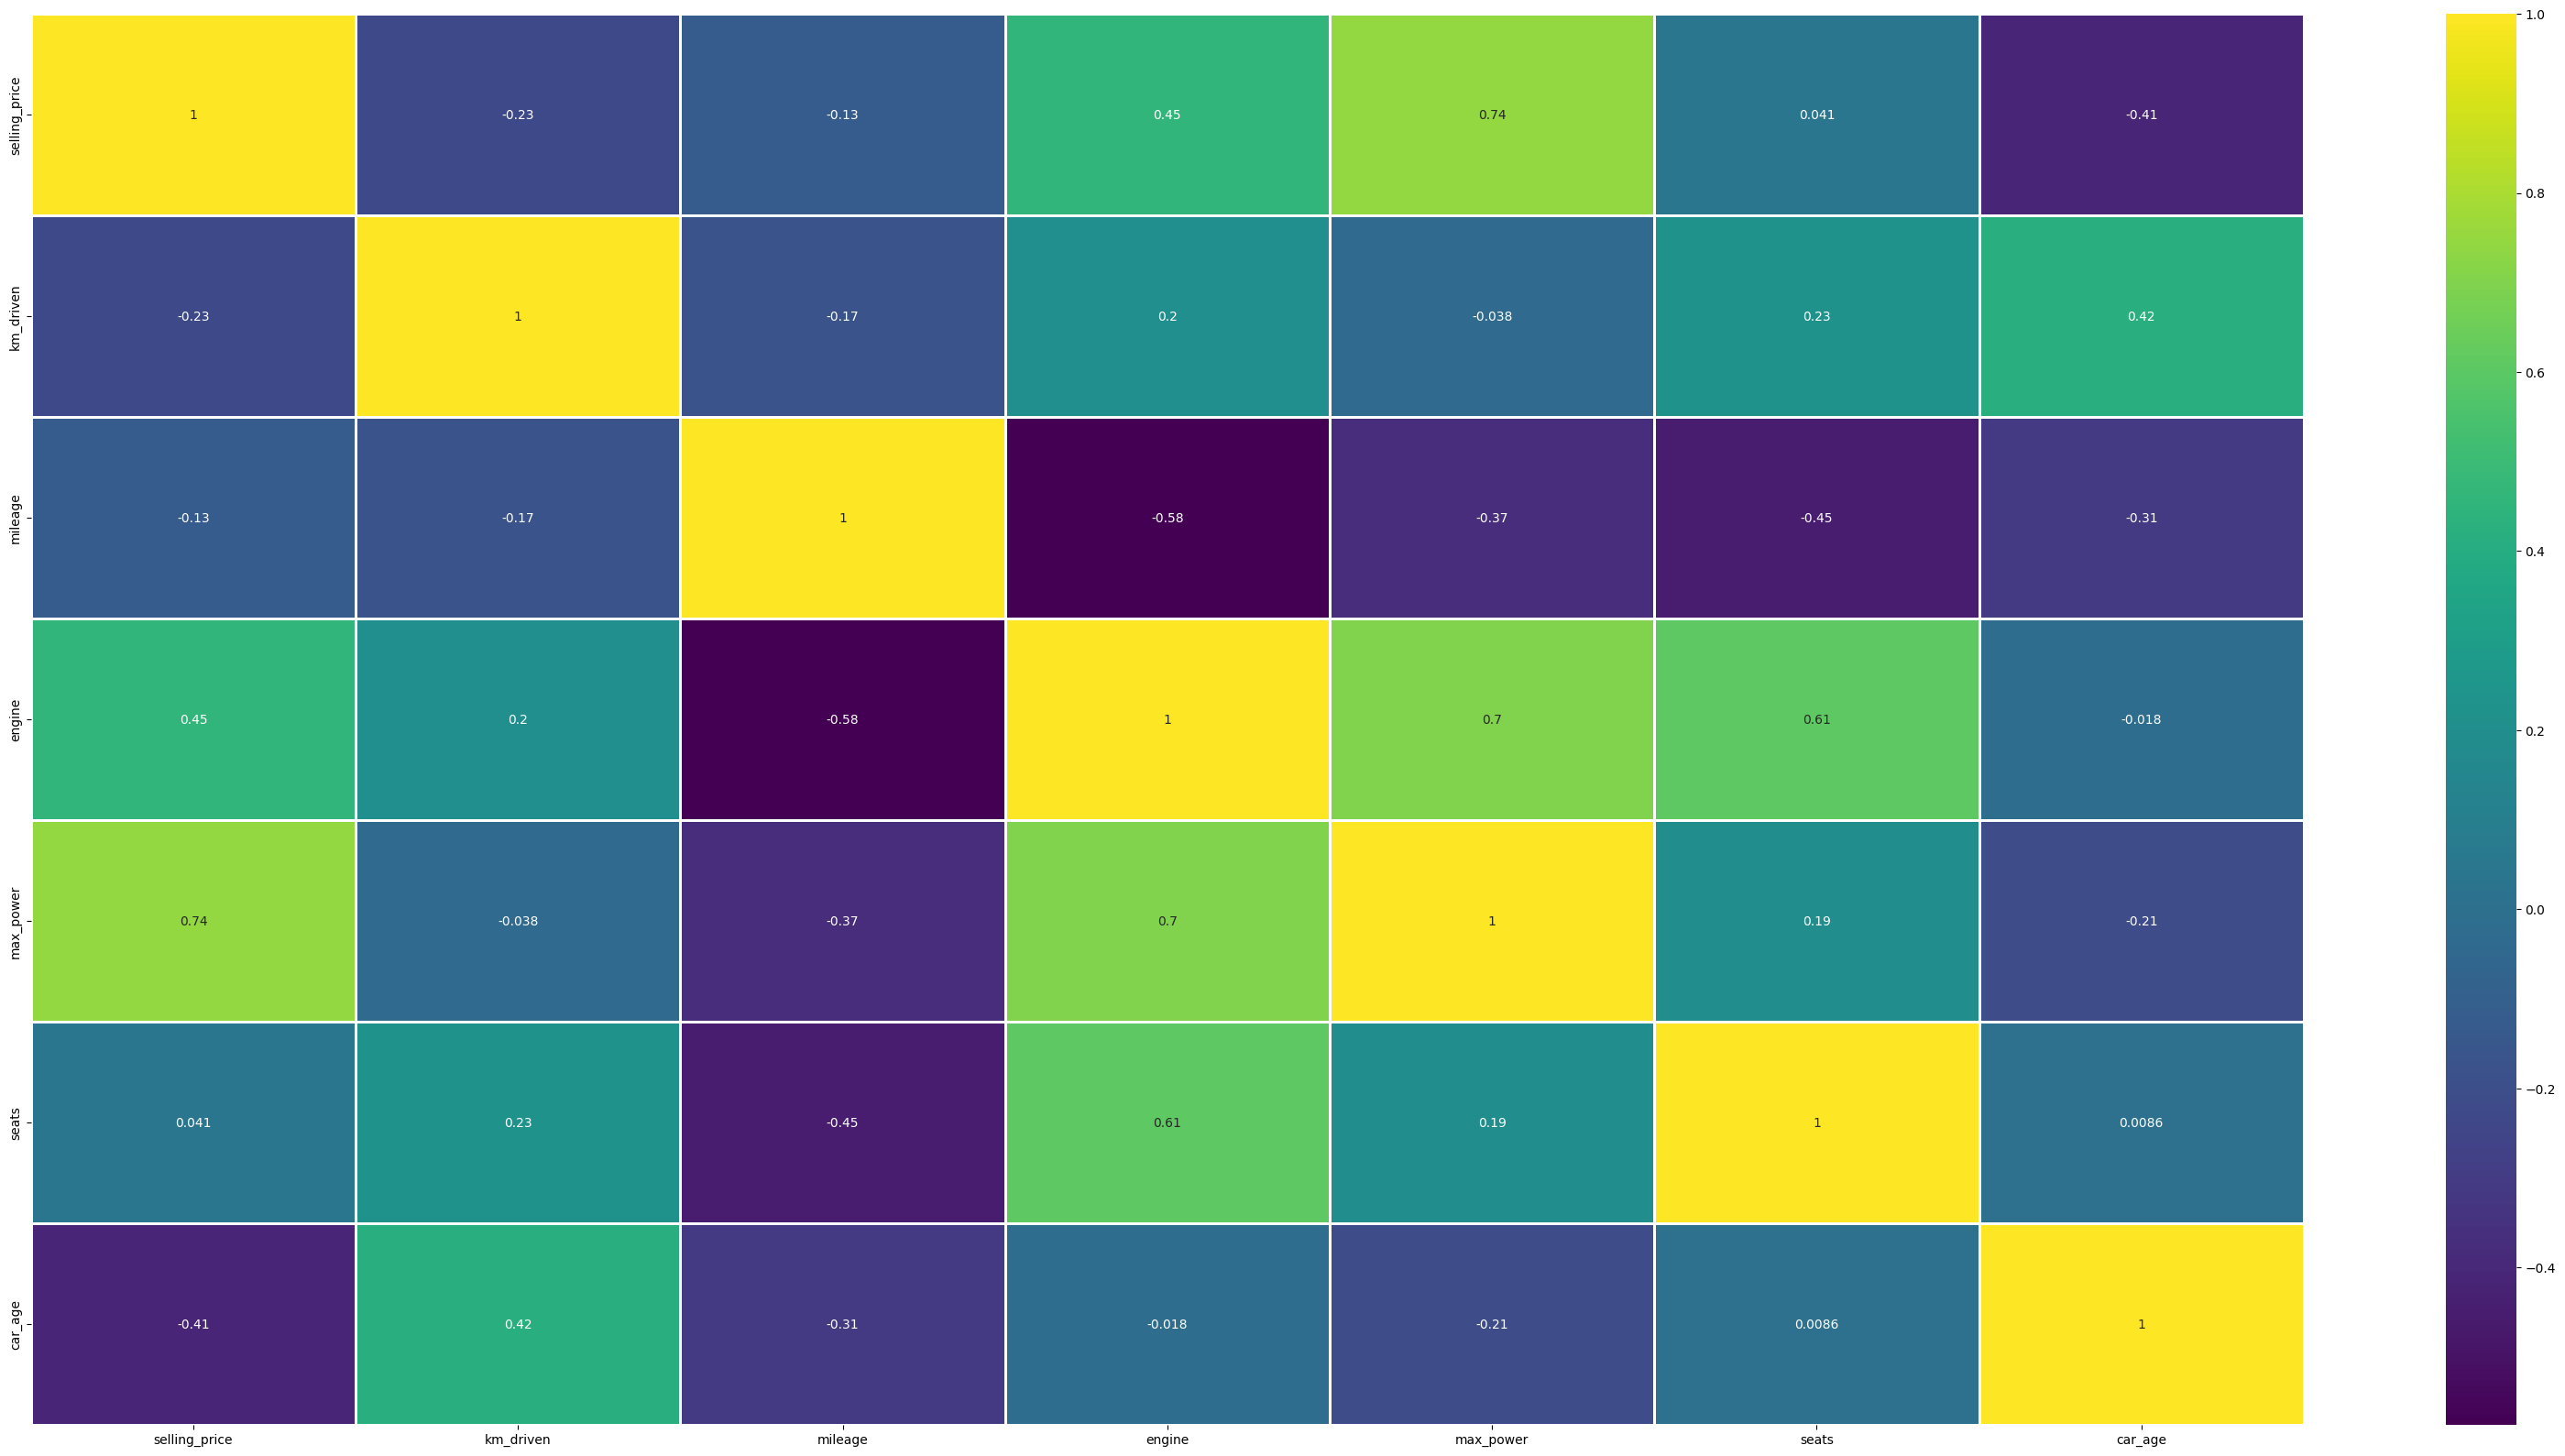

In [48]:
plt.figure(figsize=(40, 20))
sns.heatmap(df.corr(numeric_only=True), annot = True, linewidths = 2, linecolor = "white", cmap = "viridis");

In [49]:
df.corr(numeric_only=True).style.background_gradient(cmap="copper")

,selling_price,km_driven,mileage,engine,max_power,seats,car_age
selling_price,1.000000,-0.225534,-0.125454,0.453567,0.744958,0.041161,-0.414092
km_driven,-0.225534,1.000000,-0.171426,0.203954,-0.037714,0.225172,0.418006
mileage,-0.125454,-0.171426,1.000000,-0.575831,-0.373586,-0.452085,-0.310383
engine,0.453567,0.203954,-0.575831,1.000000,0.702152,0.610309,-0.017773
max_power,0.744958,-0.037714,-0.373586,0.702152,1.000000,0.191435,-0.213282
seats,0.041161,0.225172,-0.452085,0.610309,0.191435,1.000000,0.008623
car_age,-0.414092,0.418006,-0.310383,-0.017773,-0.213282,0.008623,1.000000


Multi-Collinear Independent Features
Multicollinearity means that two or more independent variables are highly correlated. They contain similar information, which can make models like linear regression unstable.

| Variables | Correlation |  
| --------------- | ------- |
| mileage ↔ engine | -0.575 |  
| max_power ↔ engine | 0.702 |  
| seats ↔ engine | 0.610 |  
| max_power ↔ selling_price | 0.744 |  

There is middle level of correlation between other variables too.

A common rule of thumb is:

|r| < 0.7 → Usually acceptable  
0.7 ≤ |r| < 0.9 → Investigate  
|r| ≥ 0.9 → Strong candidate for removing one of the variables  

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

dff = df.drop(columns='selling_price').select_dtypes(include=['int', 'float'])

vif = pd.DataFrame({
    "Feature": dff.columns,
    "VIF": [variance_inflation_factor(dff.values, i)
            for i in range(dff.shape[1])]
})

print(vif.sort_values("VIF", ascending=False))

     Feature        VIF
4      seats  43.769123
2     engine  40.157890
3  max_power  17.668306
1    mileage  14.081988
5    car_age   9.909063
0  km_driven   3.290909


In [51]:
from scipy.stats import pearsonr

pairs = [
    ("mileage", "engine"),
    ("max_power", "engine"),
    ("seats", "engine"),
    ("max_power", "selling_price"),
]

for col1, col2 in pairs:
    r, p = pearsonr(df[col1], df[col2])
    print(f"{col1:25} vs {col2:25} | r = {r:7.4f} | p = {p:.2e}")

mileage                   vs engine                    | r = -0.5758 | p = 0.00e+00
max_power                 vs engine                    | r =  0.7022 | p = 0.00e+00
seats                     vs engine                    | r =  0.6103 | p = 0.00e+00
max_power                 vs selling_price             | r =  0.7450 | p = 0.00e+00


## Fixing Skewness of the Varaibles

In [52]:
print("Basic descriptive statistics of the target variable - 'selling_price': \n\n", df["selling_price"].describe())

Basic descriptive statistics of the target variable - 'selling_price': 

 count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64


 - average of the target variable is 638271 USD
 - standard deviation of the target variable is 806253 USD
 - minimum of the target variable is 29999 USD
 - maximum of the target variable is 10000000 USD
 - median of the target variable is 450000 USD

Skewness is a statistical measure of asymmetric distribution of data while kurtosis helps determine if the distribution is heavy-tailed compared to a normal distribution. Skewness is a way of estimating and measuring the shape of a distribution. It is a vital statistical method for estimating asymmetrical behavior rather than computing the frequency distribution. Its value can be either positive or negative.

The distribution of skewness values is as below:
- Skewness = 0 when the distribution is normal
- Skewness > 0 or positive when more weight is on the left side of the distribution
- Skewness < 0 or negative when more weight is on the right side of the distribution

---

Kurtosis is a statistical term that characterizes frequency distribution. Aside from determining if a distribution is heavy-tailed, it also provides insight into the shape of the frequency distribution.
- Kurtosis of a normal distribution is equal to 3
- When the kurtosis is less than 3, it is known as platykurtic
- When the kurtosis is greater than 3, it is leptokurtic

In [53]:
print("Skewness of target variable: ", df["selling_price"].skew())
print("Kurtosis of target variable: ", df["selling_price"].kurt())

Skewness of target variable:  4.193533440675855
Kurtosis of target variable:  21.081289012186755


Positive skewness, more weight is on the left side of the distribution.  
Kurtosis is greater than 3. It is leptokurtic.  

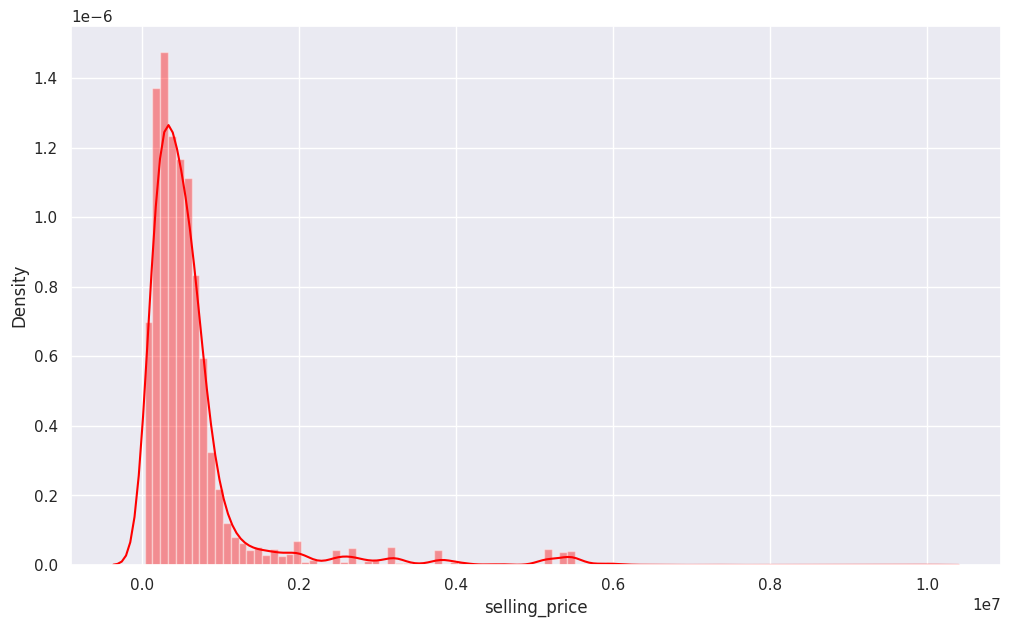

In [54]:
sns.set(rc = {"figure.figsize" : (12, 7)})
sns.distplot(df["selling_price"], bins = 100, color = "red");

We see positive skewness from the graph above. As the graphs shows, more weight is on the left side of the distribution. We will try to fix it using "log1p" function of numpy.

In [55]:
df["selling_price"] = np.log1p(df["selling_price"])
df["selling_price"].head(n = 10)

0    13.017005
1    12.821261
2    11.970357
3    12.323860
4    11.775297
5    12.994532
6    11.472114
7    10.714440
8    12.765691
9    12.206078
Name: selling_price, dtype: float64

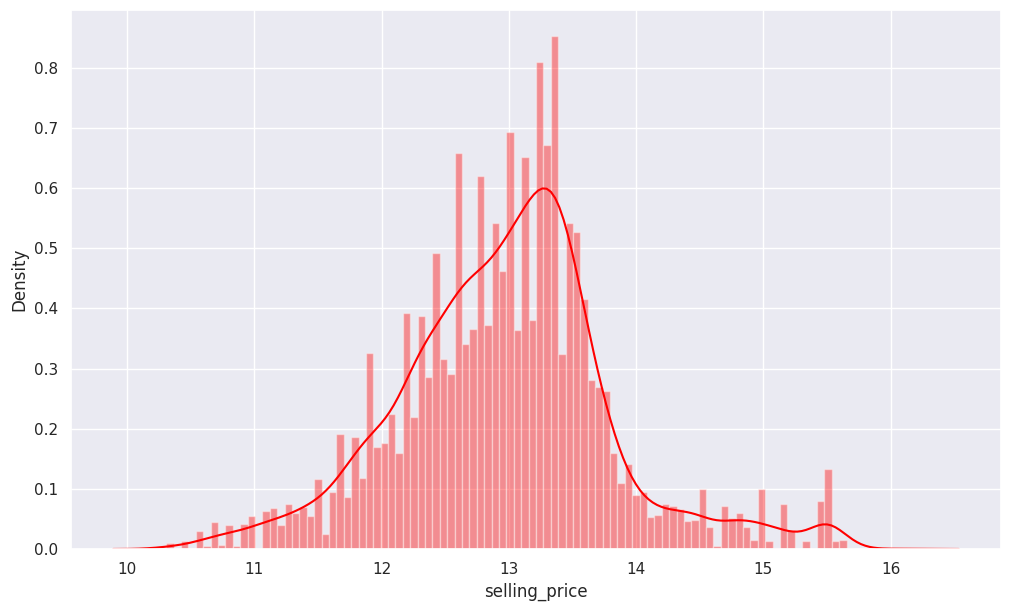

In [56]:
sns.set(rc = {"figure.figsize" : (12, 7)})
sns.distplot(df["selling_price"], bins = 100, color = "red");
# sns.histplot(df["selling_price"], bins = 100, color = "red", kde=True);

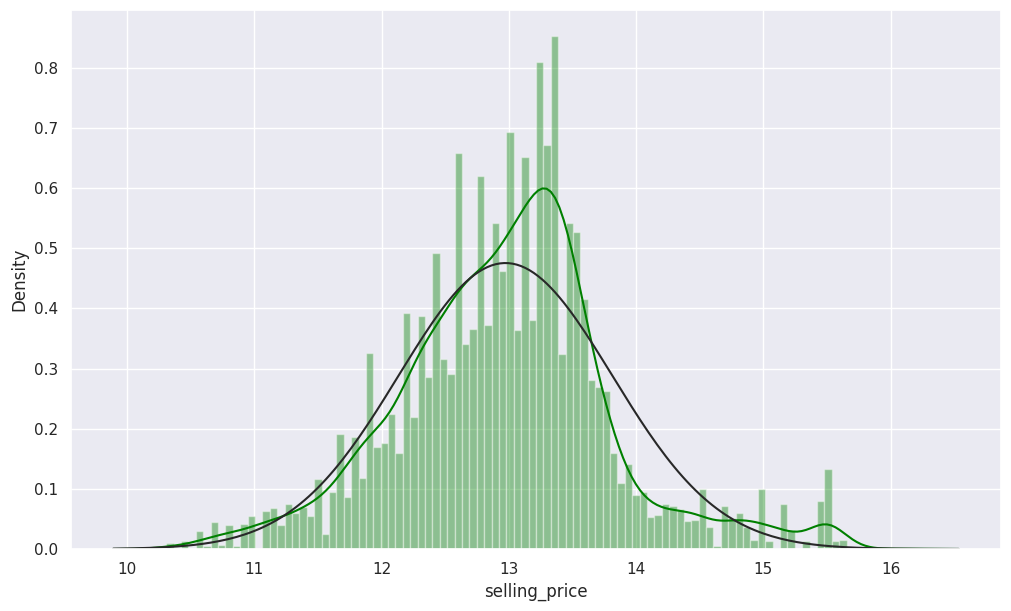

In [57]:
from scipy.stats import norm, skew

sns.distplot(df["selling_price"], bins = 100, color = "green", fit = norm);

As seen from the graph above, we could fix the skewness and distribution of target variable is normal

In [58]:
# get skewness of other numeric variables
# selling price already went through log transformation above

numeric_data = [col for col in df.select_dtypes(include=["int", "float"]).columns if col != "selling_price"]
for col in numeric_data:
    df[col] = np.log1p(df[col])

In [59]:
for c in numeric_data:
    df[c] = np.log1p(df[c])

In [60]:
df.head().style.background_gradient(cmap = "plasma")

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_brand_name,car_age
0,13.017005,2.556292,Diesel,Individual,Manual,First Owner,1.433794,2.095573,1.671001,1.026672,Maruti,1.271150
1,12.821261,2.541228,Diesel,Individual,Manual,Second Owner,1.410349,2.117767,1.731546,1.026672,Skoda,1.271150
2,11.970357,2.553297,Petrol,Individual,Manual,Third Owner,1.368264,2.117687,1.680725,1.026672,Honda,1.397363
3,12.323860,2.545684,Diesel,Individual,Manual,First Owner,1.429846,2.109253,1.706721,1.026672,Hyundai,1.343703
4,11.775297,2.541228,Petrol,Individual,Manual,First Owner,1.345232,2.100389,1.703089,1.026672,Maruti,1.385227


## Split and Encode the dataset

In [61]:
y = df["selling_price"]
X = df.drop("selling_price", axis = 1)

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6096, 11), (2032, 11), (6096,), (2032,))

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

numeric_cols = [col for col in X.select_dtypes(include=['int', 'float'])]
category_cols = [col for col in X.select_dtypes(exclude=['int', 'float'])]

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop='first', sparse_output=False), category_cols),
        ('num', RobustScaler(), numeric_cols)
    ]
)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Model Building and Evaluation

In [64]:
from sklearn.model_selection import KFold

k_fold = KFold(n_splits=10, shuffle=True, random_state=11)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LassoCV, RidgeCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from mlxtend.regressor import StackingCVRegressor

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=11)
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=11)
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=11)
rf = RandomForestRegressor(n_estimators=300, random_state=11, n_jobs=-1)
svr = SVR(C=20, kernel='rbf')
lasso = LassoCV(alphas=np.logspace(-5, 1, 30), cv=k_fold, n_jobs=-1, random_state=11)
ridge = RidgeCV(cv=k_fold)

# stacked = StackingCVRegressor(regressors=(xgb, lgbm, gbr, rf, svr, lasso), meta_regressor=xgb, cv=k_fold, shuffle=True, random_state=11, use_features_in_secondary=False)

In [65]:
from sklearn.ensemble import StackingRegressor

stacked = StackingRegressor(
    estimators=[
        ("xgb", xgb),
        ("lgbm", lgbm),
        ("gbr", gbr),
        ("rf", rf),
        ("svr", svr),
        ("lasso", lasso)
    ],
    final_estimator=xgb,
    cv=k_fold,
    n_jobs=-1
)

stacked.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.4970752208926683, tolerance: 0.3927298682139958
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.0225761713634824, tolerance: 0.393462762848272
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.4414265640514259, tolerance: 0.3913265203033679
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergen

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 5486, number of used features: 35
[LightGBM] [Info] Start training from score 12.974495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 891
[LightGBM] [Info] Number of data points in the train set: 5486, number of used features: 35
[LightGBM] [Info] Start training from score 12.977385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013499 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 894
[LightGBM] [Info] Number of data points in the train set: 5486, number of used features: 35
[LightGBM] [Info] Start training from score 12.979978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006810 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 5486, number of used features: 35
[LightGBM] [Info] Start training from score 12.977376


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011259 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 893
[LightGBM] [Info] Number of data points in the train set: 5487, number of used features: 35
[LightGBM] [Info] Start training from score 12.970774


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 5487, number of used features: 35
[LightGBM] [Info] Start training from score 12.980385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008921 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 5487, number of used features: 35
[LightGBM] [Info] Start training from score 12.974814


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.6744127462317238, tolerance: 0.35277213

StackingRegressor(cv=KFold(n_splits=10, random_state=11, shuffle=True),
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_p...
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=500, n_jobs=None,
                                               num_parallel_tree=None, ...),
                  n_jobs=-1)

In [66]:
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import cross_val_score

def cv_rmse(model, X = X_train):
    return np.sqrt(-cross_val_score(model, X_train, y_train, scoring = "neg_mean_squared_error", cv = k_fold))

def rmsle(y, y_pred):
    return np.sqrt(mean_squared_log_error(y, y_pred))

#RMSLE score of the stacked model on full TRAIN data
stacked_score_train = rmsle(y_train, stacked.predict(X_train))
print("RMSLE score of stacked models on full train data:", stacked_score_train)

#RMSLE score of the stacked model on full TEST data

stacked_score_test = rmsle(y_test, stacked.predict(X_test))
print("RMSLE score of stacked models on full test data:", stacked_score_test)

RMSLE score of stacked models on full train data: 0.011330102867611089
RMSLE score of stacked models on full test data: 0.015262010827437595


Prediction on Test Data

In [67]:
y_test[0:5]

1392    12.429220
7778    14.063933
3727    13.458837
6630    13.122365
103     12.506181
Name: selling_price, dtype: float64

In [68]:
y_pred = stacked.predict(X_test)
y_pred[0:5]

array([12.211444, 13.96953 , 13.597993, 13.030281, 12.515451],
      dtype=float32)

Training:  
price  ──log1p──► model

Prediction:  
model output ──expm1──► original price

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(stacked.predict(X_test))

print("Mean Absolute Error:", mean_absolute_error(y_test_actual, y_pred_actual))
print('Mean Squared Error:', mean_squared_error(y_test_actual, y_pred_actual))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))
print('R-squared: {}'.format(r2_score(y_test_actual, y_pred_actual)))

Mean Absolute Error: 65292.84009558011
Mean Squared Error: 14505343535.212793
Root Mean Squared Error: 120438.13156643038
R-squared: 0.9751237388610497


Text(0, 0.5, 'prediction')

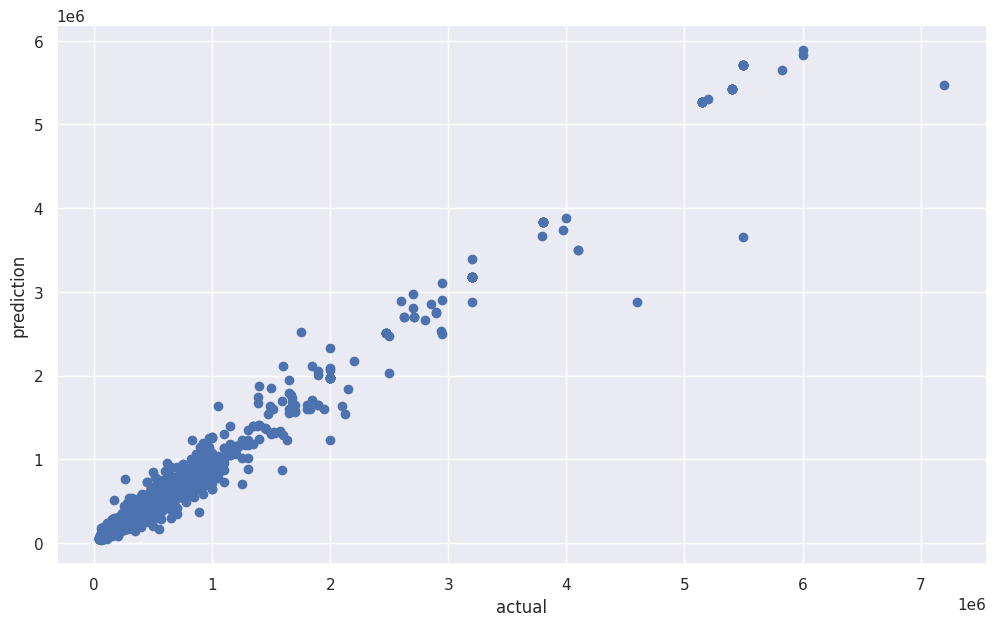

In [70]:
plt.scatter(y_test_actual, y_pred_actual);
plt.xlabel("actual")
plt.ylabel("prediction")

Text(0, 0.5, 'prediction')

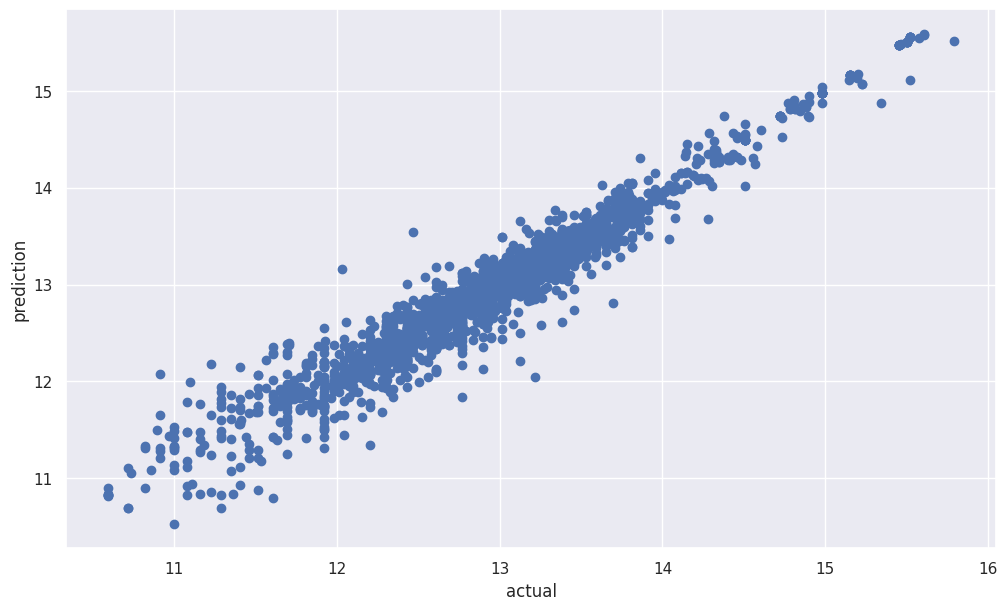

In [71]:
plt.scatter(y_test, y_pred);
plt.xlabel("actual")
plt.ylabel("prediction")